# Preamble

In [4]:
# forcing root location such that the notebook can access everything 
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [27]:
import os
import psutil
import platform

vm = psutil.virtual_memory()
swap = psutil.swap_memory()
process = psutil.Process(os.getpid())

print("Platform:", platform.platform())
print(f"Total RAM visible to Python: {vm.total / 1024**3:.2f} GB")
print(f"Available RAM right now:     {vm.available / 1024**3:.2f} GB")
print(f"Used RAM:                    {vm.used / 1024**3:.2f} GB")
print(f"RAM percent used:            {vm.percent:.1f}%")
print()
print(f"Total swap:                  {swap.total / 1024**3:.2f} GB")
print(f"Free swap:                   {swap.free / 1024**3:.2f} GB")
print()
print(f"This Jupyter kernel RSS:     {process.memory_info().rss / 1024**3:.2f} GB")

Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Total RAM visible to Python: 7.60 GB
Available RAM right now:     5.28 GB
Used RAM:                    2.32 GB
RAM percent used:            30.6%

Total swap:                  2.00 GB
Free swap:                   0.85 GB

This Jupyter kernel RSS:     0.40 GB


In [6]:
# -----------------------------------------------------------------------
# PUT AT START OF EVERY NOTEBOOK FOR MSC THESIS PROJECT

# dependencies
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import chaosmagpy as cp
import pydmd
import cmath
import copy
import h5py
import math
from scipy.signal import periodogram
from matplotlib.animation import FuncAnimation
from IPython.display import Video
from tqdm.notebook import tqdm
import pickle
from pydmd import FbDMD
from pydmd import HankelDMD
from pydmd import DMD
import gc
from scipy.interpolate import make_interp_spline
from chaosmagpy.chaos import BaseModel
import gc
import ctypes

# import paths.py to establish file structure and directories
from src.msc_thesis.paths import * # use one single python file for all paths

# importing all of the files from thesis utilities for use
from src.msc_thesis.sgdmd import * # use one single python file for all functions

# auto-update any changes to utilities code
%load_ext autoreload
%autoreload 2

# -----------------------------------------------------------------------

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Experiments (Dublin)
## Date: 23_06_2026
### Name: Dublin Experiments

**Purpose of experiment** To create findings to present at Dublin Dragon-6 conference

- impact of noise
- frequency resolution
- period recovery limits
- difference between flow and field capability (across all)

### Defining Experiment parameters

In [7]:
# defining time parameters

# note: times relative to start of synthetic time series (i.e. t=0)
t_start = 0.0 # start time
t_end = 29.5 # end time
t_record = t_end - t_start # record length
f_bin = 1 / t_record # associatied fourier resolution

dt_years = 0.2   # 6-month sampling (same as CHAOS independent information)
f_sample = 1 / dt_years    # samples per year

# getting decimal year and julian date formats
times_dyear = np.arange(t_start, t_end, dt_years)
n_times = int(len(times_dyear)) # number of total samples
print(n_times) # needs to be 148 for resolution matrix compatibility 
print(times_dyear[-1])
# choosing if decay on or not (globally)
decay = False
noise_flag = True # toggles whatever noise is on

if decay:
    sigma='default'
else:
    sigma=0

# select desired modes:
input_modes_global = np.array([47, 51, 60, 61])


148
29.400000000000002


### Retrieving Felix Synthetic Data

In [8]:
# make array to store recovered eigenvalues for each component
eig_array = np.zeros((len(input_modes_global), 4),dtype=complex)

# true vs recovered spatial pattern:
# make array to store (normalised?) difference
norm_diff_array = np.zeros((len(input_modes_global), 3))

# make array to store correlation coefficient 
corr_array = np.zeros((len(input_modes_global), 3))

# ------------------- MAIN DATA RETRIEVAL -------------------------------

input_wave_data = []

# for each input mode, add it to total data storage
for i, mode_number in enumerate(tqdm(input_modes_global)):

    mode_i_data = [mode_number]

    gnm_mf, gnm_sv, br, sv, utheta, uphi, eigenvalue = Felix_Wave_Obtain(times_dyear, mode_number,bin_choice='wave-centred', sigma=sigma)

    mode_i_data = {
        "mode_number": mode_number,
        "gnm_mf":gnm_mf,
        "gnm_sv":gnm_sv,
        "br": br,
        "sv": sv,
        "utheta": utheta,
        "uphi": uphi,
        "eigenvalue": eigenvalue,
        # filled later
        "best_match_idx": { # list as need to store for each noise realisation
            "br": [],
            "sv": [],
            "utheta": [],
            "uphi": []
        }
    }

    input_wave_data.append(mode_i_data) # input_wave_data = data dictionary for mode i

# total inputs, the old way - some code uses these, should probably try to update
# getting total inputs
# could really properly implement SV here
tot_input_br = Total_Input_Evaluate(input_wave_data, times_dyear, "br")
tot_input_sv = Total_Input_Evaluate(input_wave_data, times_dyear, "sv")
# use SV instead of mainfield, for waves it is just phase shifted Br, therefore no advantage to MF/Br
tot_input_utheta = Total_Input_Evaluate(input_wave_data, times_dyear, "utheta")
tot_input_uphi = Total_Input_Evaluate(input_wave_data, times_dyear, "uphi")

# get power quality control
#Power_QC(tot_input_sv, times_dyear, input_wave_freqs, scaling='spectrum')

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 21.47it/s]


### Functions to truncate stored gauss coefficient type data sets by SH order

In [15]:

def n_Gauss_Coeffs(lmax):
    """
    Number of internal-field Gauss coefficients up to spherical harmonic degree lmax,
    using standard geomagnetic ordering with g_l^m and h_l^m.

    Count = sum_{l=1}^{lmax} (2l + 1) = lmax(lmax + 2)
    """
    return lmax * (lmax + 2)


def Truncate_Gauss_Coeffs(gnm, lmax):
    """
    Truncate a Gauss coefficient vector or array of vectors to spherical harmonic degree lmax.

    Assumes standard ordering:
        g10,
        g11, h11,
        g20, g21, h21, g22, h22,
        ...

    Assumes coefficient axis is the final axis.

    Parameters
    ----------
    gnm : array-like
        Gauss coefficient vector or array of vectors.
        Examples:
            (ncoeff,)
            (nt, ncoeff)
            (nmodes, nt, ncoeff)

    lmax : int
        Maximum spherical harmonic degree to retain.

    Returns
    -------
    gnm_trunc : np.ndarray
        Input array truncated along the final axis.
    """
    gnm = np.asarray(gnm)

    n_keep = n_Gauss_Coeffs(lmax)

    if gnm.shape[-1] < n_keep:
        raise ValueError(
            f"Input only has {gnm.shape[-1]} coefficients, "
            f"but lmax={lmax} requires {n_keep}."
        )

    return gnm[..., :n_keep]

### RAM handling functions (for debugging)

In [10]:
# RAM monitor

import csv
import os
import time
import psutil
import threading
from datetime import datetime


def ram_monitor_csv(stop_event, csv_path="ram_log.csv", interval=5, warn_available_gb=2.0):
    process = psutil.Process(os.getpid())

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "time",
            "available_gb",
            "used_gb",
            "total_gb",
            "kernel_rss_gb",
            "swap_used_gb",
            "ram_percent",
            "warning"
        ])

        while not stop_event.is_set():
            vm = psutil.virtual_memory()
            swap = psutil.swap_memory()
            rss_gb = process.memory_info().rss / 1024**3

            available_gb = vm.available / 1024**3
            used_gb = vm.used / 1024**3
            total_gb = vm.total / 1024**3
            swap_used_gb = swap.used / 1024**3

            warning = available_gb < warn_available_gb

            writer.writerow([
                datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                available_gb,
                used_gb,
                total_gb,
                rss_gb,
                swap_used_gb,
                vm.percent,
                warning
            ])

            f.flush()

            time.sleep(interval)

In [11]:
def run_with_ram_monitor_csv(
    func,
    *args,
    csv_path="ram_log.csv",
    interval=5,
    warn_available_gb=2.0,
    **kwargs
):
    stop_event = threading.Event()

    monitor_thread = threading.Thread(
        target=ram_monitor_csv,
        args=(stop_event,),
        kwargs={
            "csv_path": csv_path,
            "interval": interval,
            "warn_available_gb": warn_available_gb,
        },
        daemon=True
    )

    monitor_thread.start()

    try:
        result = func(*args, **kwargs)

    finally:
        stop_event.set()
        monitor_thread.join()

    return result

### Reading in resolution matrix one sub-matrix (P, R, H) at a time

In [ ]:
# function to read in relevant resolution matrix file
# takes in MF form gauss coefficients, returns sv post resolution matrix 
def R_Read_In(R_part, which="SV"):
    f = h5py.File((f'{CHAOS_RESOL_DIR}/CHAOS_Resol_1997_2026_0806_{which}.h5'),"r")

    R_sub_matrix = np.asarray(f[R_part])

    f.close()
    return R_sub_matrix

### Function to pull out nmax 20 gauss coefficient time series for R matrix input

In [ ]:
# making function to obtain gnm for main field, for resolution matrix
def R_Input_Gnm_Obtain(input_wave_data, times, nmax_res=20):

    # getting mf gauss coefficient time series for total synthetic input
    total_gnm_no_truncation = Wave_Gnm_Total_Obtain(input_wave_data, times_dyear, "mf")

    # truncating to nmax = 20
    total_gnm_nmax_truncated = Truncate_Gauss_Coeffs(total_gnm_no_truncation, lmax=nmax_res)

    return(total_gnm_nmax_truncated)

res_input_gnm = R_Input_Gnm_Obtain(input_wave_data, times_dyear)

# getting the true SV gauss coefficients in time
# this is by: pulling out MF gauss coeffs supplied by felix, multiplying by eigenvalue (by wave)
# to get sv gauss coefficients by wave, storing these, summing to get total sv gauss coefficients in time
true_input_gnm_sv = Wave_Gnm_Total_Obtain(input_wave_data, times_dyear, "sv")

### RAM conserving handling of the resolution matrix application

In [28]:
def Clear_Ram():
    """
    Force Python garbage collection and, on Linux/WSL, ask glibc to release
    freed heap memory back to the OS where possible.
    """
    gc.collect()

    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass


def R_Apply_Ram_Cleanup(gnm):
    """
    Same logic as your original R_Apply, but each resolution-matrix component
    is deleted as soon as it is no longer needed.
    """

    # -------------------------
    # Apply P
    # -------------------------
    P = R_Read_In(R_part="P")
    gnm_spl = P @ gnm

    del P
    Clear_Ram()

    # -------------------------
    # Apply R
    # -------------------------
    R = R_Read_In(R_part="R")

    gnm_spl_vec = gnm_spl.ravel(order="F")
    gnm_filt_spl_vec = R @ gnm_spl_vec
    gnm_filt_spl = np.reshape(
        gnm_filt_spl_vec,
        gnm_spl.shape,
        order="F"
    )

    del R, gnm_spl_vec, gnm_filt_spl_vec
    Clear_Ram()

    # -------------------------
    # Apply H
    # -------------------------
    H = R_Read_In(R_part="H")

    gnm_deriv = H @ gnm_spl
    gnm_filt = H @ gnm_filt_spl

    del H, gnm_spl, gnm_filt_spl
    Clear_Ram()

    return gnm_deriv, gnm_filt

In [29]:
#gnm_deriv, gnm_filt = run_with_ram_monitor_csv(
#    R_Apply_Ram_Cleanup,
#    res_input_gnm,
#    csv_path=f"{FIG_DIR}/R_apply_ram_log.csv",
#    interval=2,
#    warn_available_gb=4.0
#)

In [ ]:
resolved_gnm_deriv, resolved_gnm_filt = R_Apply_Ram_Cleanup(res_input_gnm)

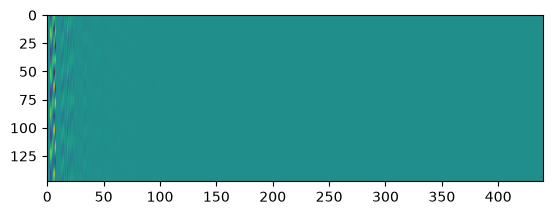

In [ ]:
plt.imshow(resolved_gnm_filt)

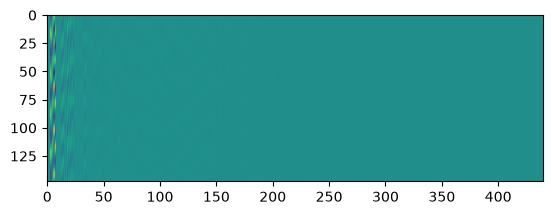

In [ ]:
plt.imshow(Truncate_Gauss_Coeffs(true_input_gnm_sv, lmax=20))

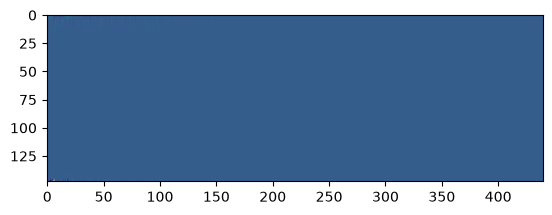

In [ ]:
plt.imshow(resolved_gnm_filt- Truncate_Gauss_Coeffs(true_input_gnm_sv, lmax=20) )

In [ ]:
# total_input_field... function basically takes sv gauss coefficient time series, converts to 
# spline model using chaosmagpy, then evaluates the 

tot_field_post_res = Total_Input_Field_Make_From_Gnm(resolved_gnm_filt, times_dyear)

done! just need to convert into real field on grid


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/chaosmagpy/model_utils.py:506: UserWarning: Input coordinates include the poles.
  warnings.warn('Input coordinates include the poles.')


In [ ]:
tot_field_pre_res = Total_Input_Field_Make_From_Gnm(true_input_gnm_sv, times_dyear)

done! just need to convert into real field on grid


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/chaosmagpy/model_utils.py:506: UserWarning: Input coordinates include the poles.
  warnings.warn('Input coordinates include the poles.')


In [ ]:
Cube_Movie(tot_field_post_res["sv"], name="tot_field_post_res", fig_dir=FIG_DIR, fps=5, cmap="seismic")

'/home/elliott/projects/msc_thesis_project/figures/tot_field_post_res.mp4'

In [ ]:
Cube_Movie(tot_field_pre_res["sv"], name="tot_field_pre_res", fig_dir=FIG_DIR, fps=5, cmap="seismic")

'/home/elliott/projects/msc_thesis_project/figures/tot_field_pre_res.mp4'

In [ ]:
# below shows absolute point wise error between total input via gauss coeffs and via old implementation
# found minor difference (~5% of total nT) at the very highest spatial frequency regions - likely irrelevant
'''n_step = 5
im = plt.imshow(np.abs(sv_total_input[n_step] - Series_To_Cube(tot_input_sv)[n_step]))
plt.colorbar(im)
plt.show()'''

'n_step = 5\nim = plt.imshow(np.abs(sv_total_input[n_step] - Series_To_Cube(tot_input_sv)[n_step]))\nplt.colorbar(im)\nplt.show()'

In [ ]:
import os
import psutil

process = psutil.Process(os.getpid())

def mem_report(label=""):
    rss_gb = process.memory_info().rss / 1024**3
    print(f"{label:30s} | RAM used by kernel: {rss_gb:.3f} GB")

In [ ]:


for wave_data_i in input_wave_data:
    wave_data_i["best_match_idx"] = {
        "sv": [],
        "gnm_sv": [],
        "utheta": [],
        "uphi": []
    }

def empty_component_performance():
    return {
        "recovered_eigenvalues": [],
        "spatial_correlations": [],
        "norm_spatial_errors": []
    }

performance_summary = []

for wave_data_i in input_wave_data:

    wave_summary_dict_i = {
        "true_eigenvalue": wave_data_i["eigenvalue"],
        "sv": empty_component_performance(),
        "gnm_sv": empty_component_performance(),
        "utheta": empty_component_performance(),
        "uphi": empty_component_performance(),
    }
    
    performance_summary.append(wave_summary_dict_i)
    print(len(performance_summary))

    # storing in dictionary
    tot_input_dict = {
      "sv": tot_input_sv,
      "gnm_sv": tot_input_gnm_sv, 
      "utheta": tot_input_utheta,
      "uphi": tot_input_uphi
    }
        

    # ----------------------------------------------------------------------------------
    # RUNNING DMD
    # ----------------------------------------------------------------------------------
    
    components = ["sv", "gnm_sv", "utheta","uphi"]
    
    # make a dictionary that stores each components dmd results
    # for component c: store continuous eigenvalues, phasors in order
    # could add discrete later, not now
    
    output_mode_data = {
        "sv": [],
        "gnm_sv": [],
        "utheta": [],
        "uphi": [] 
    }
    
    
    # getting out all of the phasors and eigenvalues for the modes of each component
    for j, c in enumerate(components):
        
        # tot_input_c = tot_input_dict[c]
        tot_input_c = np.asarray(tot_input_dict[c])

        dmd = DMD(exact=True, svd_rank=-1) # create dmd object, no truncation
        dmd.fit(tot_input_c) # fit it to data
        raw_modes, eigenvalues, amplitudes = dmd.modes, dmd.eigs, dmd.amplitudes
        modes = raw_modes * amplitudes[np.newaxis, :]
        modes = modes[0:int(len(theta)*len(phi)), :]
        # retrieve data
        dmd_out = [modes, eigenvalues]
    
        # pairing the DMD modes
        mode_indices = DMD_Mode_Pair(dmd_out)
    
        dmd_c_phasors_continuous = []
        dmd_c_eigenvalues_discrete = []
    
        # have mode indices, now go through each mode pairing (i.e. element in mode_indices)
        # check which eigenvalue has positive frequency - use that and spatial mode associated with it
        for idx_set in mode_indices:
    
            if isinstance(idx_set, tuple):
                idx_a, idx_b = idx_set
                eigenvalue_a, eigenvalue_b = eigenvalues[idx_a], eigenvalues[idx_b]
                if D_To_C_Eigenvalue_Converter(eigenvalue_a, dt=dt_years).imag > 0:
                    eig_discrete = eigenvalue_a
                    phasor_continuous = 2 * modes[:, idx_a]
                else:
                    eig_discrete = eigenvalue_b
                    phasor_continuous = 2 * modes[:, idx_b]
            else:
                eig_discrete = eigenvalues[idx_set]
                phasor_continuous = modes[:, idx_set]
    
            eig_continuous = D_To_C_Eigenvalue_Converter(eig_discrete, dt=dt_years)

            if np.shape(phasor_continuous)[0] == 65160: # handle differently on if it needs reshaping or not
                output_mode_data[c].append({
                    "eigenvalue_continuous": eig_continuous,
                    "phasor_continuous": phasor_continuous.reshape(state_shape)
                })
            else:
                output_mode_data[c].append({
                    "eigenvalue_continuous": eig_continuous,
                    "phasor_continuous": phasor_continuous
                })
        del dmd, raw_modes, eigenvalues, amplitudes, modes, dmd_out
    
        # getting total output and computing similarity - block out for kernel
        # tot_output_c = Total_Output_Evaluate(dmd_out, times_dyear)
        # tot_output_dict[c]=tot_output_c
        # tot_input_c = tot_input_dict[c]
    
        # norm_diff_c = np.linalg.norm(tot_output_c - tot_input_c) / np.linalg.norm(tot_input_c)
    # ----------------------------------------------------------------------------------
    # MATCHING INPUTS WAVES TO OUTPUT MODES
    # ----------------------------------------------------------------------------------


# for each input mode
for i, mode in enumerate(input_modes_global):
    print(i, len(input_modes_global))

    # get data dictionary for mode i
    mode_i_data_dict = input_wave_data[i]
    mode = mode_i_data_dict["mode_number"]
    input_eigenvalue = mode_i_data_dict["eigenvalue"]

    # getting input period
    input_period_i = (2*np.pi)/input_eigenvalue.imag

    # for each component at input mode i
    for j, c in enumerate(components):

        # get input phasor
        input_phasor = mode_i_data_dict[c]
        
        # retrieving DMD outputs for this component
        dmd_eigenvalues_continuous_c = np.array([row["eigenvalue_continuous"] for row in output_mode_data[c]])
        dmd_phasors_continuous_c = np.array([row["phasor_continuous"] for row in output_mode_data[c]])

        # get candidate indices - i.e. where period error < 10 %
        # use this as a mask moving forward
        period_error = period_relative_error(input_eigenvalue, dmd_eigenvalues_continuous_c)
        candidates = np.where(period_error<1)[0] # allow less than 10% period error, returns dmd indices

        # now compute pattern error of each candidate, and keep highest
        # if none > 0.9 correlation, consider no match made.
        match_flag = False
        current_best_corr = 0

        # placeholder for no match
        best_match_i_c = np.nan
        # for all modes with <10% period error
        for cand_idx in candidates:

            # getting dmd phasor, calculate correlation
            if np.shape(dmd_phasors_continuous_c[cand_idx])[0] == 65160:
                output_phasor_candidate = dmd_phasors_continuous_c[cand_idx].reshape(state_shape)
            else:
                output_phasor_candidate = dmd_phasors_continuous_c[cand_idx]

            candidate_corr = Complex_Corr(output_phasor_candidate, input_phasor)

            # if the candidate has correlation >90%, store it as current best match
            # highest correlation = best match overall
            if candidate_corr >= 0:
                if candidate_corr > current_best_corr:
                    match_flag = True
                    current_best_corr = candidate_corr
                    # storing best match candidate idx
                    best_match_i_c = cand_idx

        # if a match is found for the input mode, store it
        if match_flag:
            match_phasor = dmd_phasors_continuous_c[best_match_i_c]
            input_wave_data[i]["best_match_idx"][c].append(best_match_i_c)
            performance_summary[i][c]["recovered_eigenvalues"].append(dmd_eigenvalues_continuous_c[best_match_i_c])
            performance_summary[i][c]["spatial_correlations"].append(Complex_Corr(input_phasor, match_phasor))
            performance_summary[i][c]["norm_spatial_errors"].append(Spatial_Relative_Error(input_phasor, match_phasor))
        else:
            input_wave_data[i]["best_match_idx"][c].append("no match")
            performance_summary[i][c]["recovered_eigenvalues"].append(np.nan)
            performance_summary[i][c]["spatial_correlations"].append(np.nan)
            performance_summary[i][c]["norm_spatial_errors"].append(np.nan)

            
mem_report()
gc.collect

1


NameError: name 'tot_input_gnm_sv' is not defined

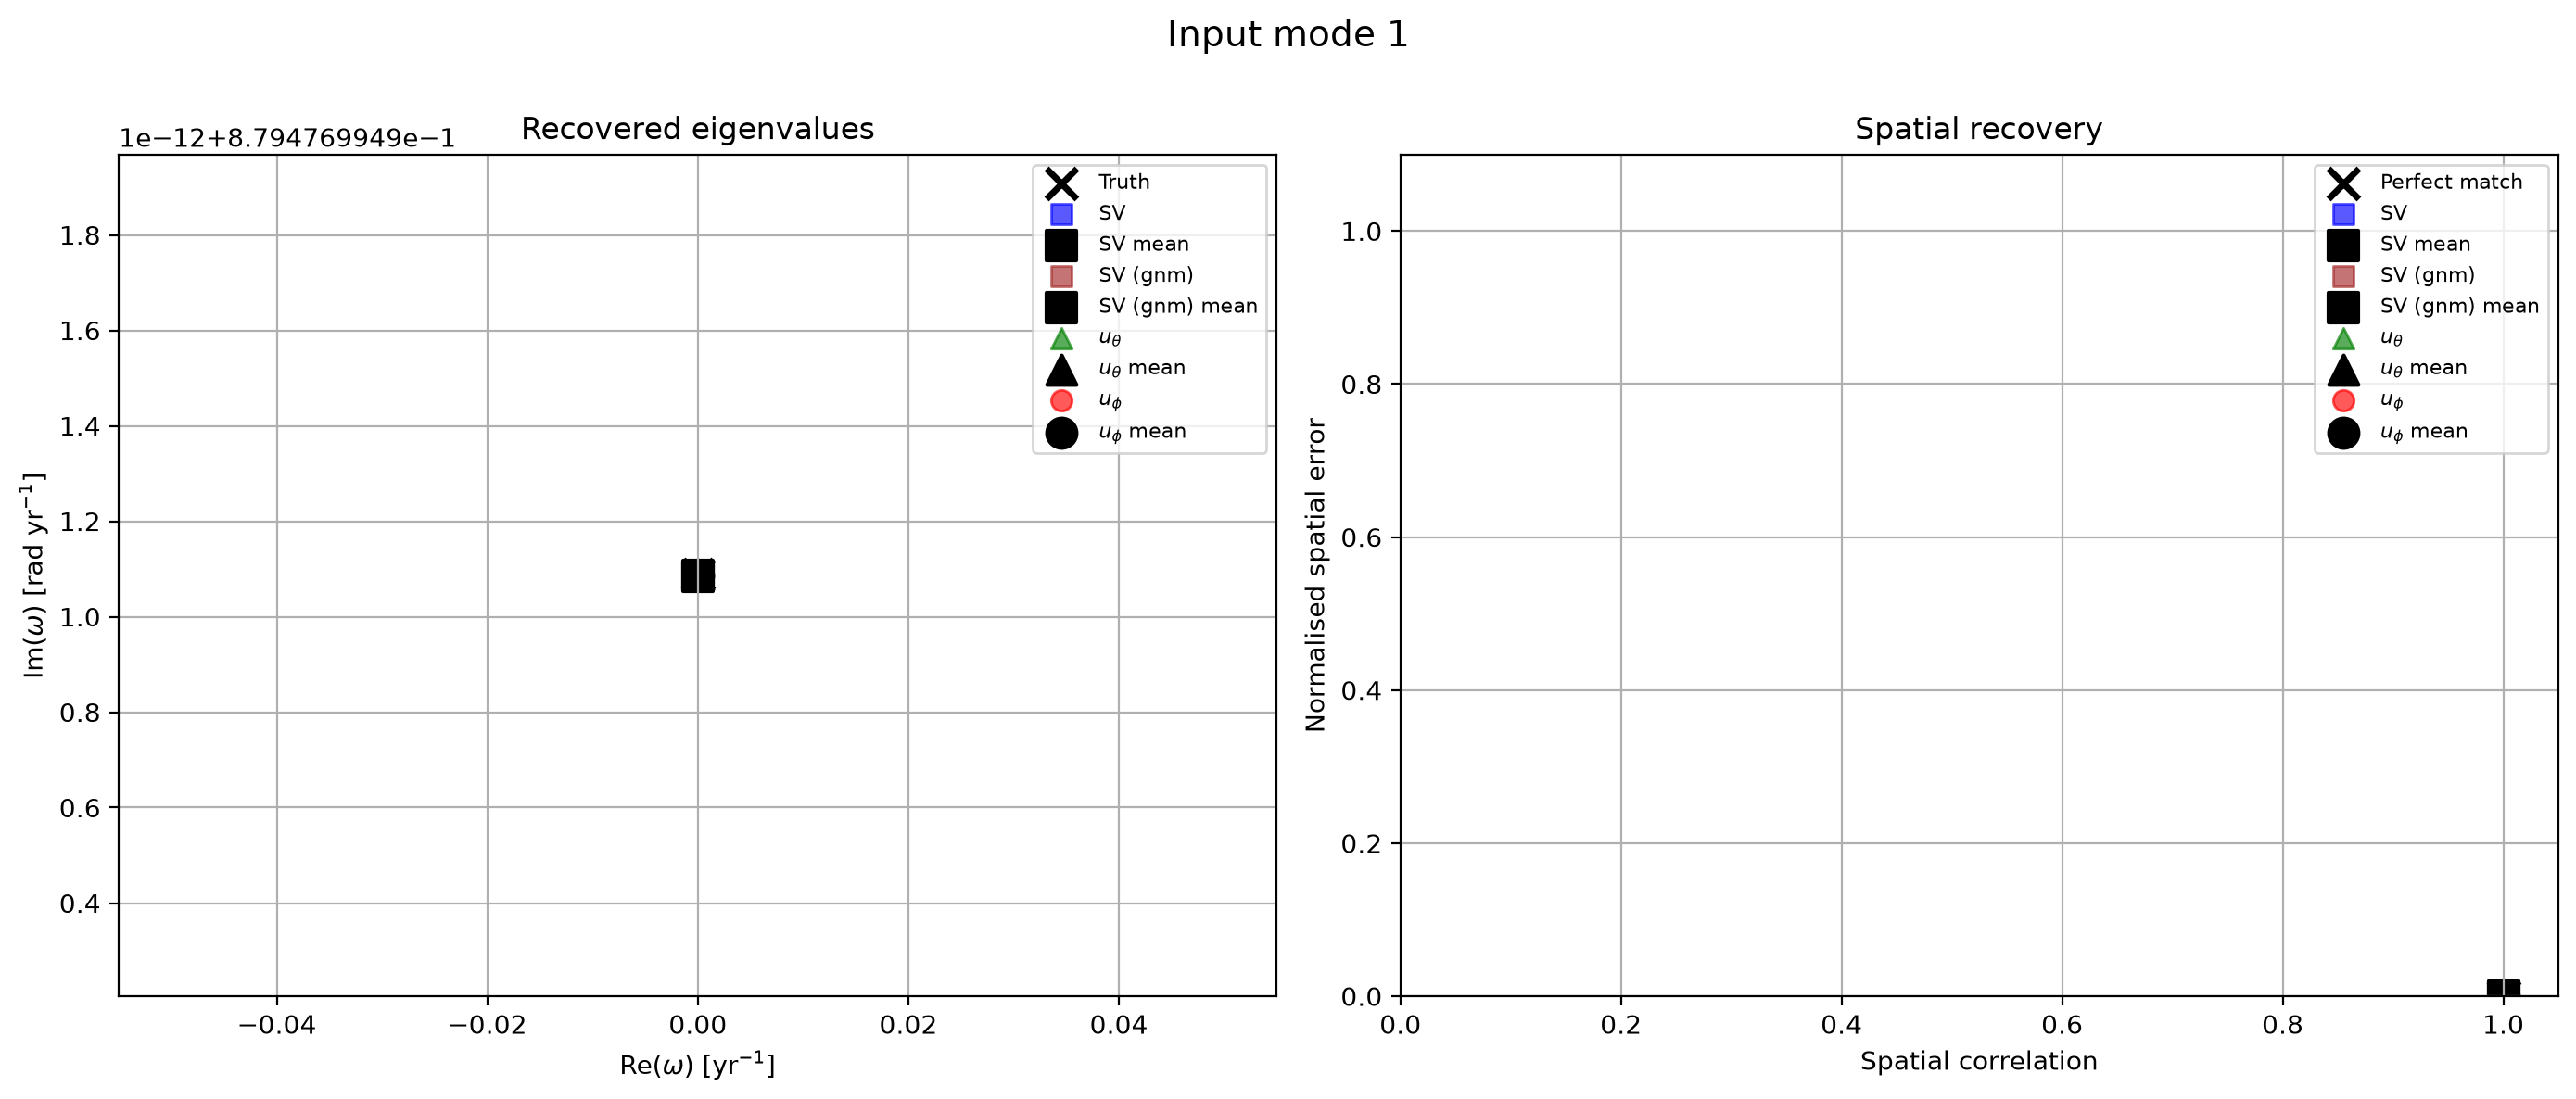

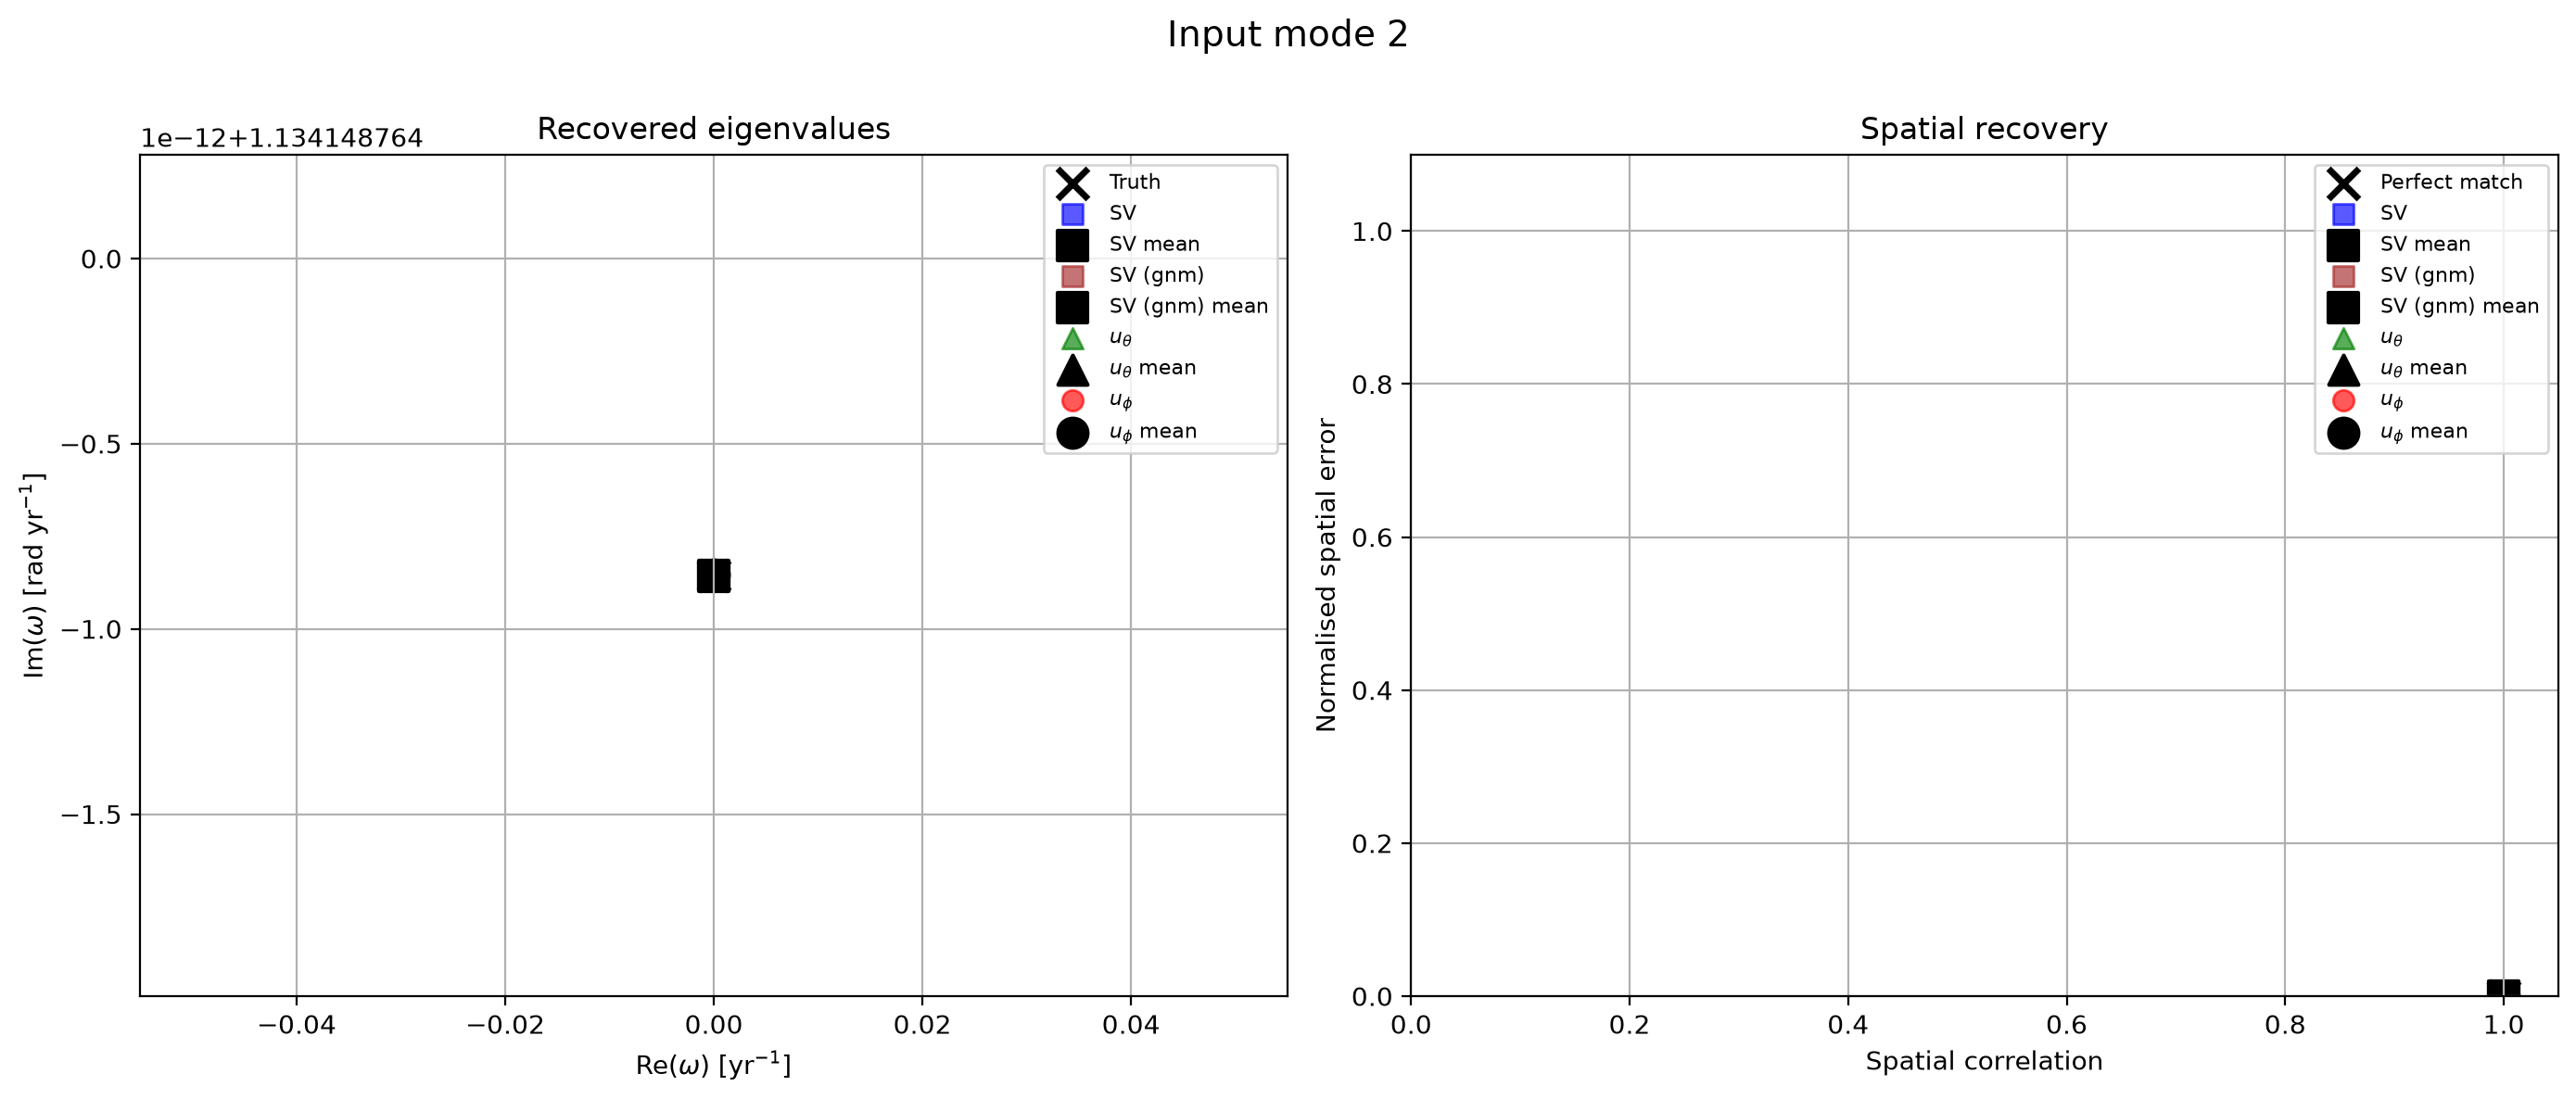

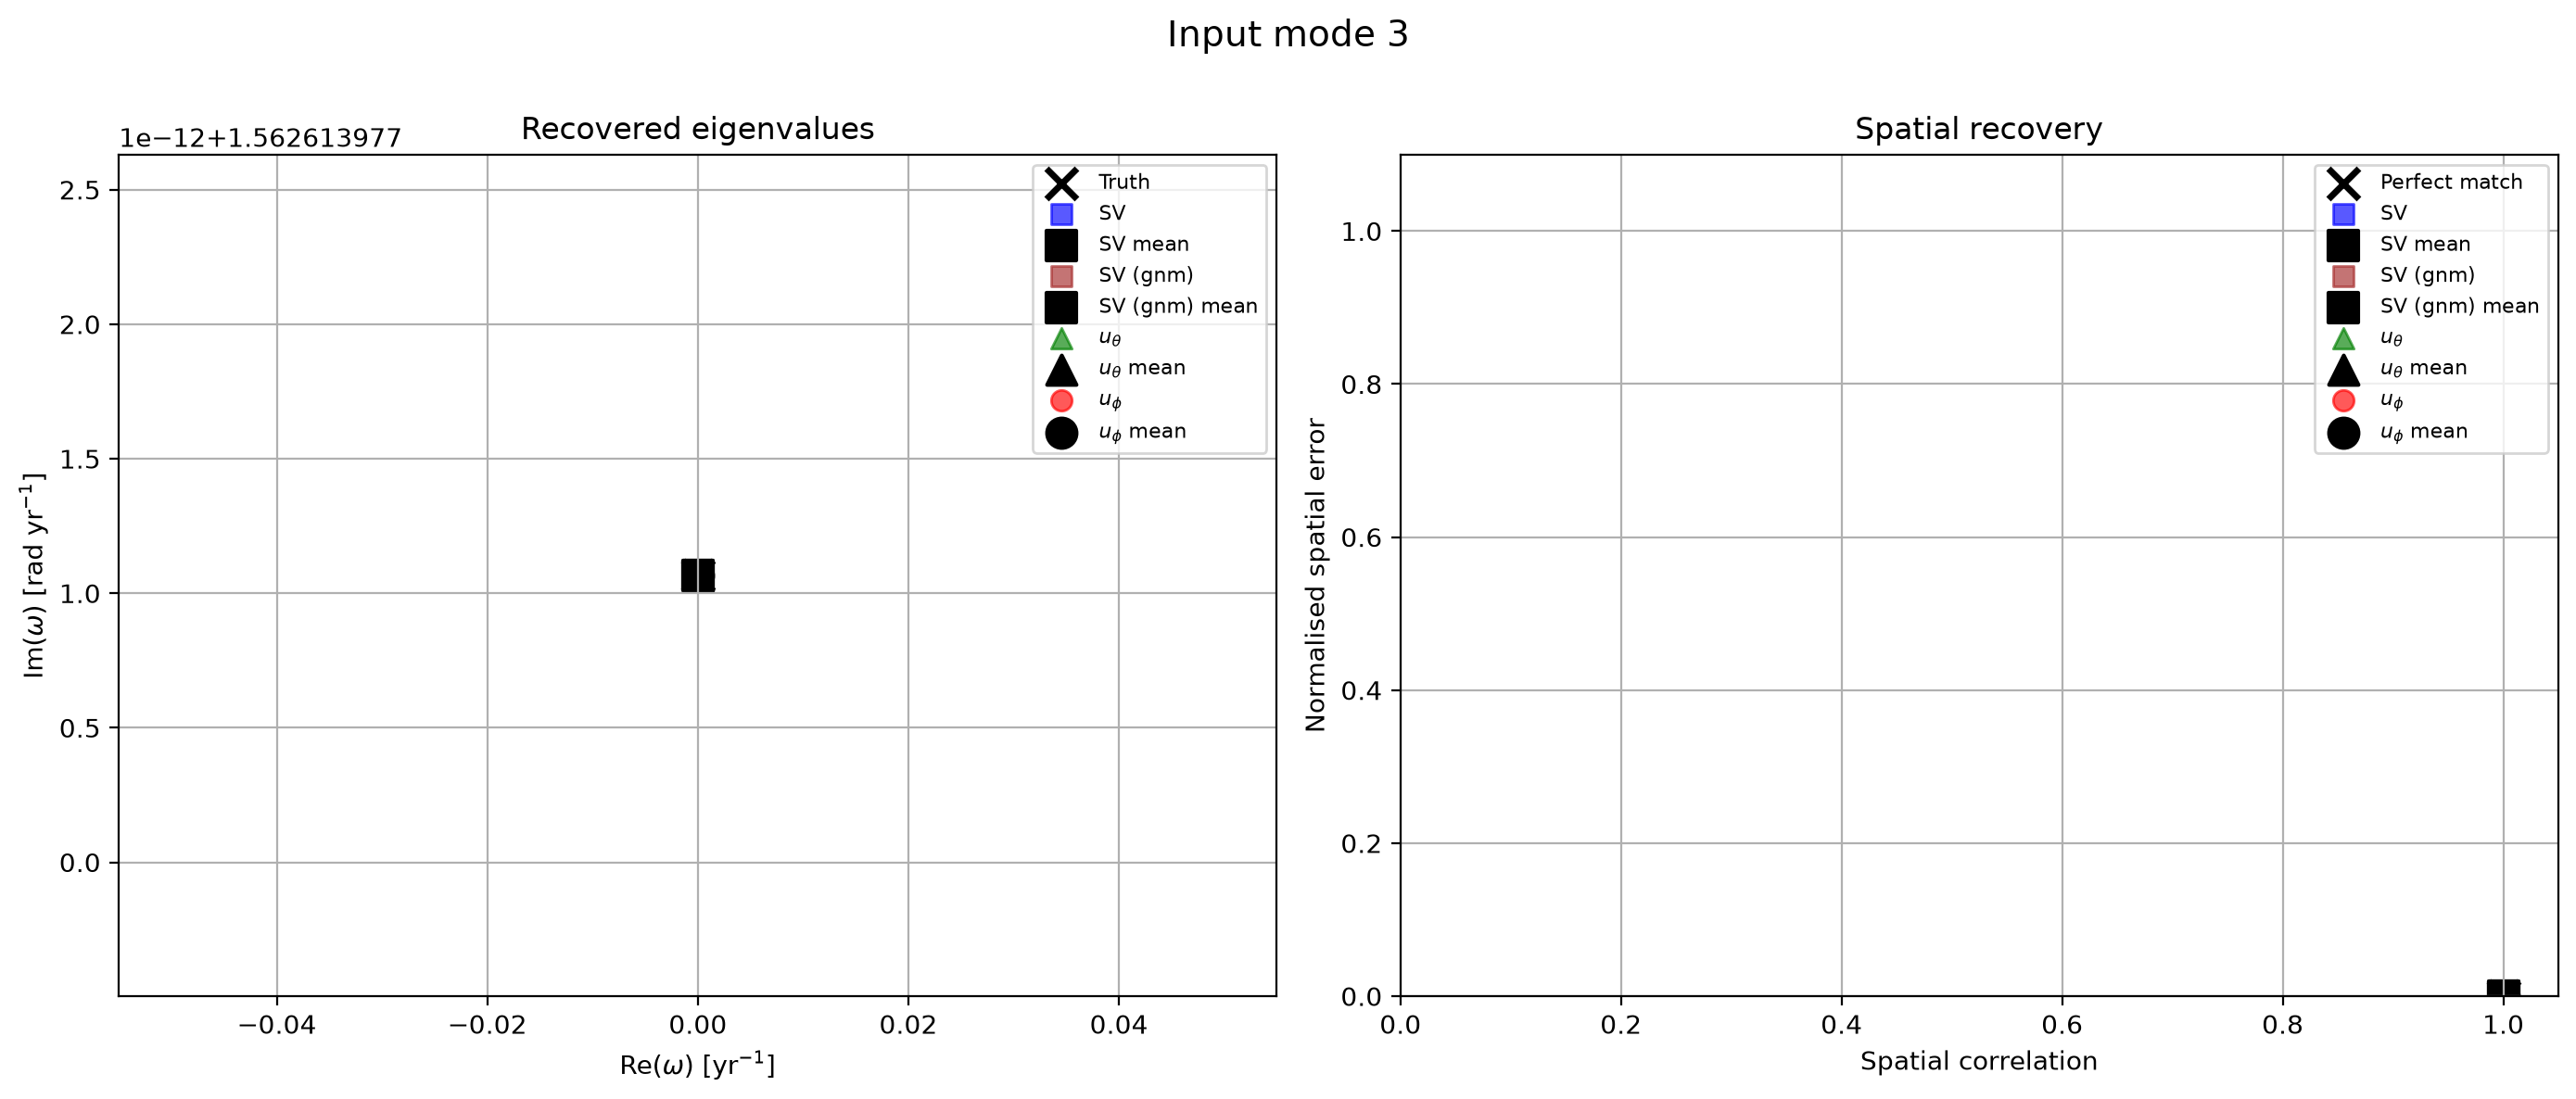

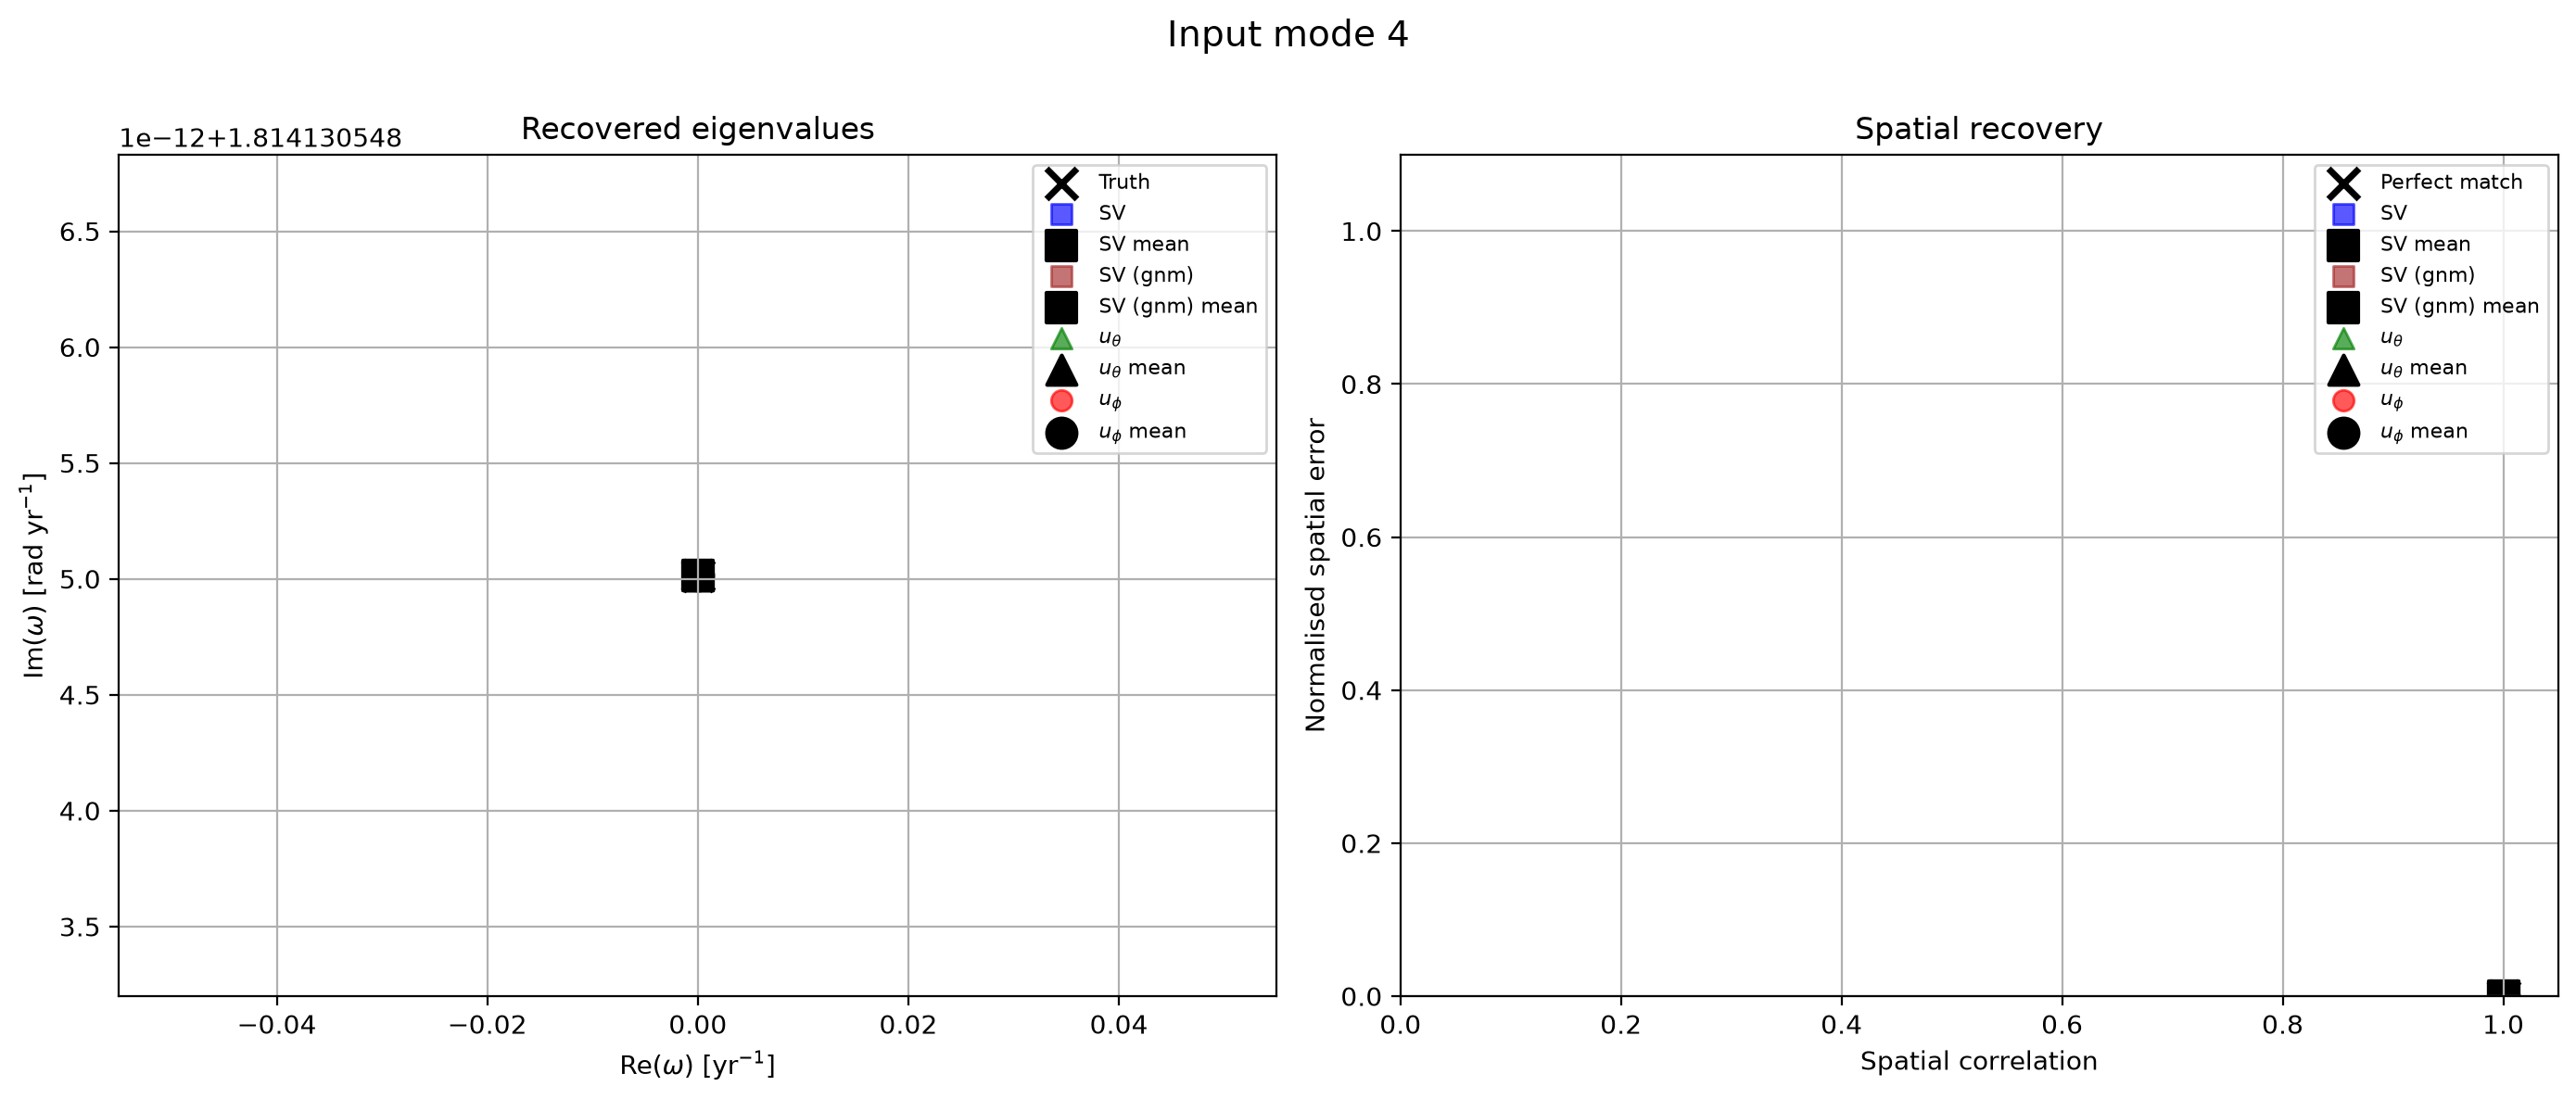

In [ ]:
plot_performance_summary(performance_summary, save_dir=FIG_DIR)

In [ ]:
# Gauss coefficient based

# each element = dmd output for a noise realisation
if noise_flag:
    noise_seed_list = np.arange(1, 10, 1)
else:
    noise_seed_list = [0]

for wave_data_i in input_wave_data:
    wave_data_i["best_match_idx"] = {
        "sv": [],
        "utheta": [],
        "uphi": []
    }


# want to store:
# - eigenvalue, spatial correlation, normalised spatial difference
'''
want each element to be a dictionary for a mode
for each mode want:
- true eigenvalue
- set of component stats
- for each component stat, want:
- eigenvalue, correlation, norm difference for match

initialise dict that has:
true eigenvalue
dict with:
- components
within each lists for eigenvalues, spatial correlation, spatial norm error
'''

def empty_component_performance():
    return {
        "recovered_eigenvalues": [],
        "spatial_correlations": [],
        "norm_spatial_errors": []
    }

performance_summary = []

for wave_data_i in input_wave_data:

    wave_summary_dict_i = {
        "true_eigenvalue": wave_data_i["eigenvalue"],
        "sv": empty_component_performance(),
        "utheta": empty_component_performance(),
        "uphi": empty_component_performance(),
    }
    
    performance_summary.append(wave_summary_dict_i)

for noise_seed in tqdm(noise_seed_list):

    
    # ----------------------------------------------------------------------------------
    # ADDING NOISE
    # ----------------------------------------------------------------------------------
    if noise_flag:
    
        # getting rng from a seed
        rng = np.random.default_rng(noise_seed)
        
        # get total powers of each component - deprecated, no use for now
        power_suite = Felix_Power_Suite(input_wave_data)
        total_component_powers = power_suite[-1]
        p_sv, p_utheta, p_uphi = total_component_powers
    
        component_noise = {
            "sv":None,
        }
        
       
        for c in component_noise:
            noise = Power_Law_Coloured_Noise(times_dyear, c=c, rng=rng)
            noise = Spatially_Smooth_Noise(noise) 
            component_noise[c] = noise
            
        
        # add it to each component
        tot_input_sv_noised = tot_input_sv.copy() + Cube_To_Series(component_noise["sv"])

        del component_noise
        
        # storing in dictionary
        tot_input_dict = {
          "sv": tot_input_sv_noised,
          "utheta": tot_input_utheta_noised,
          "uphi": tot_input_uphi_noised
        }
        
        tot_output_dict = {
          "sv": None,
          "utheta": None,
          "uphi": None
        }

    else:
        # storing in dictionary
        tot_input_dict = {
          "sv": tot_input_sv,
          "utheta": tot_input_utheta,
          "uphi": tot_input_uphi
        }
        

    # ----------------------------------------------------------------------------------
    # RUNNING DMD
    # ----------------------------------------------------------------------------------
    
    components = ["sv","utheta","uphi"]
    
    # make a dictionary that stores each components dmd results
    # for component c: store continuous eigenvalues, phasors in order
    # could add discrete later, not now
    
    output_mode_data = {
        "sv": [],
        "utheta": [],
        "uphi": [] 
    }
    
    
    # getting out all of the phasors and eigenvalues for the modes of each component
    for j, c in enumerate(components):
        
        # tot_input_c = tot_input_dict[c]
        tot_input_c = np.asarray(tot_input_dict[c])

        DMD = DMD(exact=True, svd_rank=-1) # create dmd object, no truncation
        DMD.fit(tot_input_c) # fit it to data
        raw_modes, eigenvalues, amplitudes = DMD.modes, DMD.eigs, DMD.amplitudes
        modes = raw_modes * amplitudes[np.newaxis, :]
        modes = modes[0:int(len(theta)*len(phi)), :]
        
        # retrieve data
        dmd_out = [modes, eigenvalues]
    
        # pairing the DMD modes
        mode_indices = DMD_Mode_Pair(dmd_out)
    
        dmd_c_phasors_continuous = []
        dmd_c_eigenvalues_discrete = []
    
        # have mode indices, now go through each mode pairing (i.e. element in mode_indices)
        # check which eigenvalue has positive frequency - use that and spatial mode associated with it
        for idx_set in mode_indices:
    
            if isinstance(idx_set, tuple):
                idx_a, idx_b = idx_set
                eigenvalue_a, eigenvalue_b = eigenvalues[idx_a], eigenvalues[idx_b]
                if D_To_C_Eigenvalue_Converter(eigenvalue_a, dt=dt_years).imag > 0:
                    eig_discrete = eigenvalue_a
                    phasor_continuous = 2 * modes[:, idx_a]
                else:
                    eig_discrete = eigenvalue_b
                    phasor_continuous = 2 * modes[:, idx_b]
            else:
                eig_discrete = eigenvalues[idx_set]
                phasor_continuous = modes[:, idx_set]
    
            eig_continuous = D_To_C_Eigenvalue_Converter(eig_discrete, dt=dt_years)
    
            output_mode_data[c].append({
                "eigenvalue_continuous": eig_continuous,
                "phasor_continuous": phasor_continuous.reshape(state_shape)
            })
        del fbdmd, raw_modes, eigenvalues, amplitudes, modes, dmd_out
    
        # getting total output and computing similarity - block out for kernel
        # tot_output_c = Total_Output_Evaluate(dmd_out, times_dyear)
        # tot_output_dict[c]=tot_output_c
        # tot_input_c = tot_input_dict[c]
    
        # norm_diff_c = np.linalg.norm(tot_output_c - tot_input_c) / np.linalg.norm(tot_input_c)
    # ----------------------------------------------------------------------------------
    # MATCHING INPUTS WAVES TO OUTPUT MODES
    # ----------------------------------------------------------------------------------
    
    
    # for each input mode
    for i, mode in enumerate(input_modes_global):
    
        # get data dictionary for mode i
        mode_i_data_dict = input_wave_data[i]
        mode = mode_i_data_dict["mode_number"]
        input_eigenvalue = mode_i_data_dict["eigenvalue"]
    
        # getting input period
        input_period_i = (2*np.pi)/input_eigenvalue.imag
    
        # for each component at input mode i
        for j, c in enumerate(components):
    
            # get input phasor
            input_phasor = mode_i_data_dict[c]
            
            # retrieving DMD outputs for this component
            dmd_eigenvalues_continuous_c = np.array([row["eigenvalue_continuous"] for row in output_mode_data[c]])
            dmd_phasors_continuous_c = np.array([row["phasor_continuous"] for row in output_mode_data[c]])
    
            # get candidate indices - i.e. where period error < 10 %
            # use this as a mask moving forward
            period_error = period_relative_error(input_eigenvalue, dmd_eigenvalues_continuous_c)
            candidates = np.where(period_error<1)[0] # allow less than 10% period error, returns dmd indices
    
            # now compute pattern error of each candidate, and keep highest
            # if none > 0.9 correlation, consider no match made.
            match_flag = False
            current_best_corr = 0
    
            # placeholder for no match
            best_match_i_c = np.nan
            # for all modes with <10% period error
            for cand_idx in candidates:
    
                # getting dmd phasor, calculate correlation
                output_phasor_candidate = dmd_phasors_continuous_c[cand_idx].reshape(state_shape)
                candidate_corr = Complex_Corr(output_phasor_candidate, input_phasor)
    
                # if the candidate has correlation >90%, store it as current best match
                # highest correlation = best match overall
                if candidate_corr >= 0:
                    if candidate_corr > current_best_corr:
                        match_flag = True
                        current_best_corr = candidate_corr
                        # storing best match candidate idx
                        best_match_i_c = cand_idx
    
            # if a match is found for the input mode, store it
            if match_flag:
                match_phasor = dmd_phasors_continuous_c[best_match_i_c]
                input_wave_data[i]["best_match_idx"][c].append(best_match_i_c)
                performance_summary[i][c]["recovered_eigenvalues"].append(dmd_eigenvalues_continuous_c[best_match_i_c])
                performance_summary[i][c]["spatial_correlations"].append(Complex_Corr(input_phasor, match_phasor))
                performance_summary[i][c]["norm_spatial_errors"].append(Spatial_Relative_Error(input_phasor, match_phasor))
            else:
                input_wave_data[i]["best_match_idx"][c].append("no match")
                performance_summary[i][c]["recovered_eigenvalues"].append(np.nan)
                performance_summary[i][c]["spatial_correlations"].append(np.nan)
                performance_summary[i][c]["norm_spatial_errors"].append(np.nan)

                
    mem_report()
    gc.collect

In [ ]:
import psutil

vm = psutil.virtual_memory()

print(f"Total system RAM:     {vm.total / 1024**3:.2f} GB")
print(f"Available system RAM: {vm.available / 1024**3:.2f} GB")
print(f"Used system RAM:      {vm.used / 1024**3:.2f} GB")
print(f"Percent used:         {vm.percent:.1f}%")

Total system RAM:     47.04 GB
Available system RAM: 41.17 GB
Used system RAM:      4.79 GB
Percent used:         12.5%


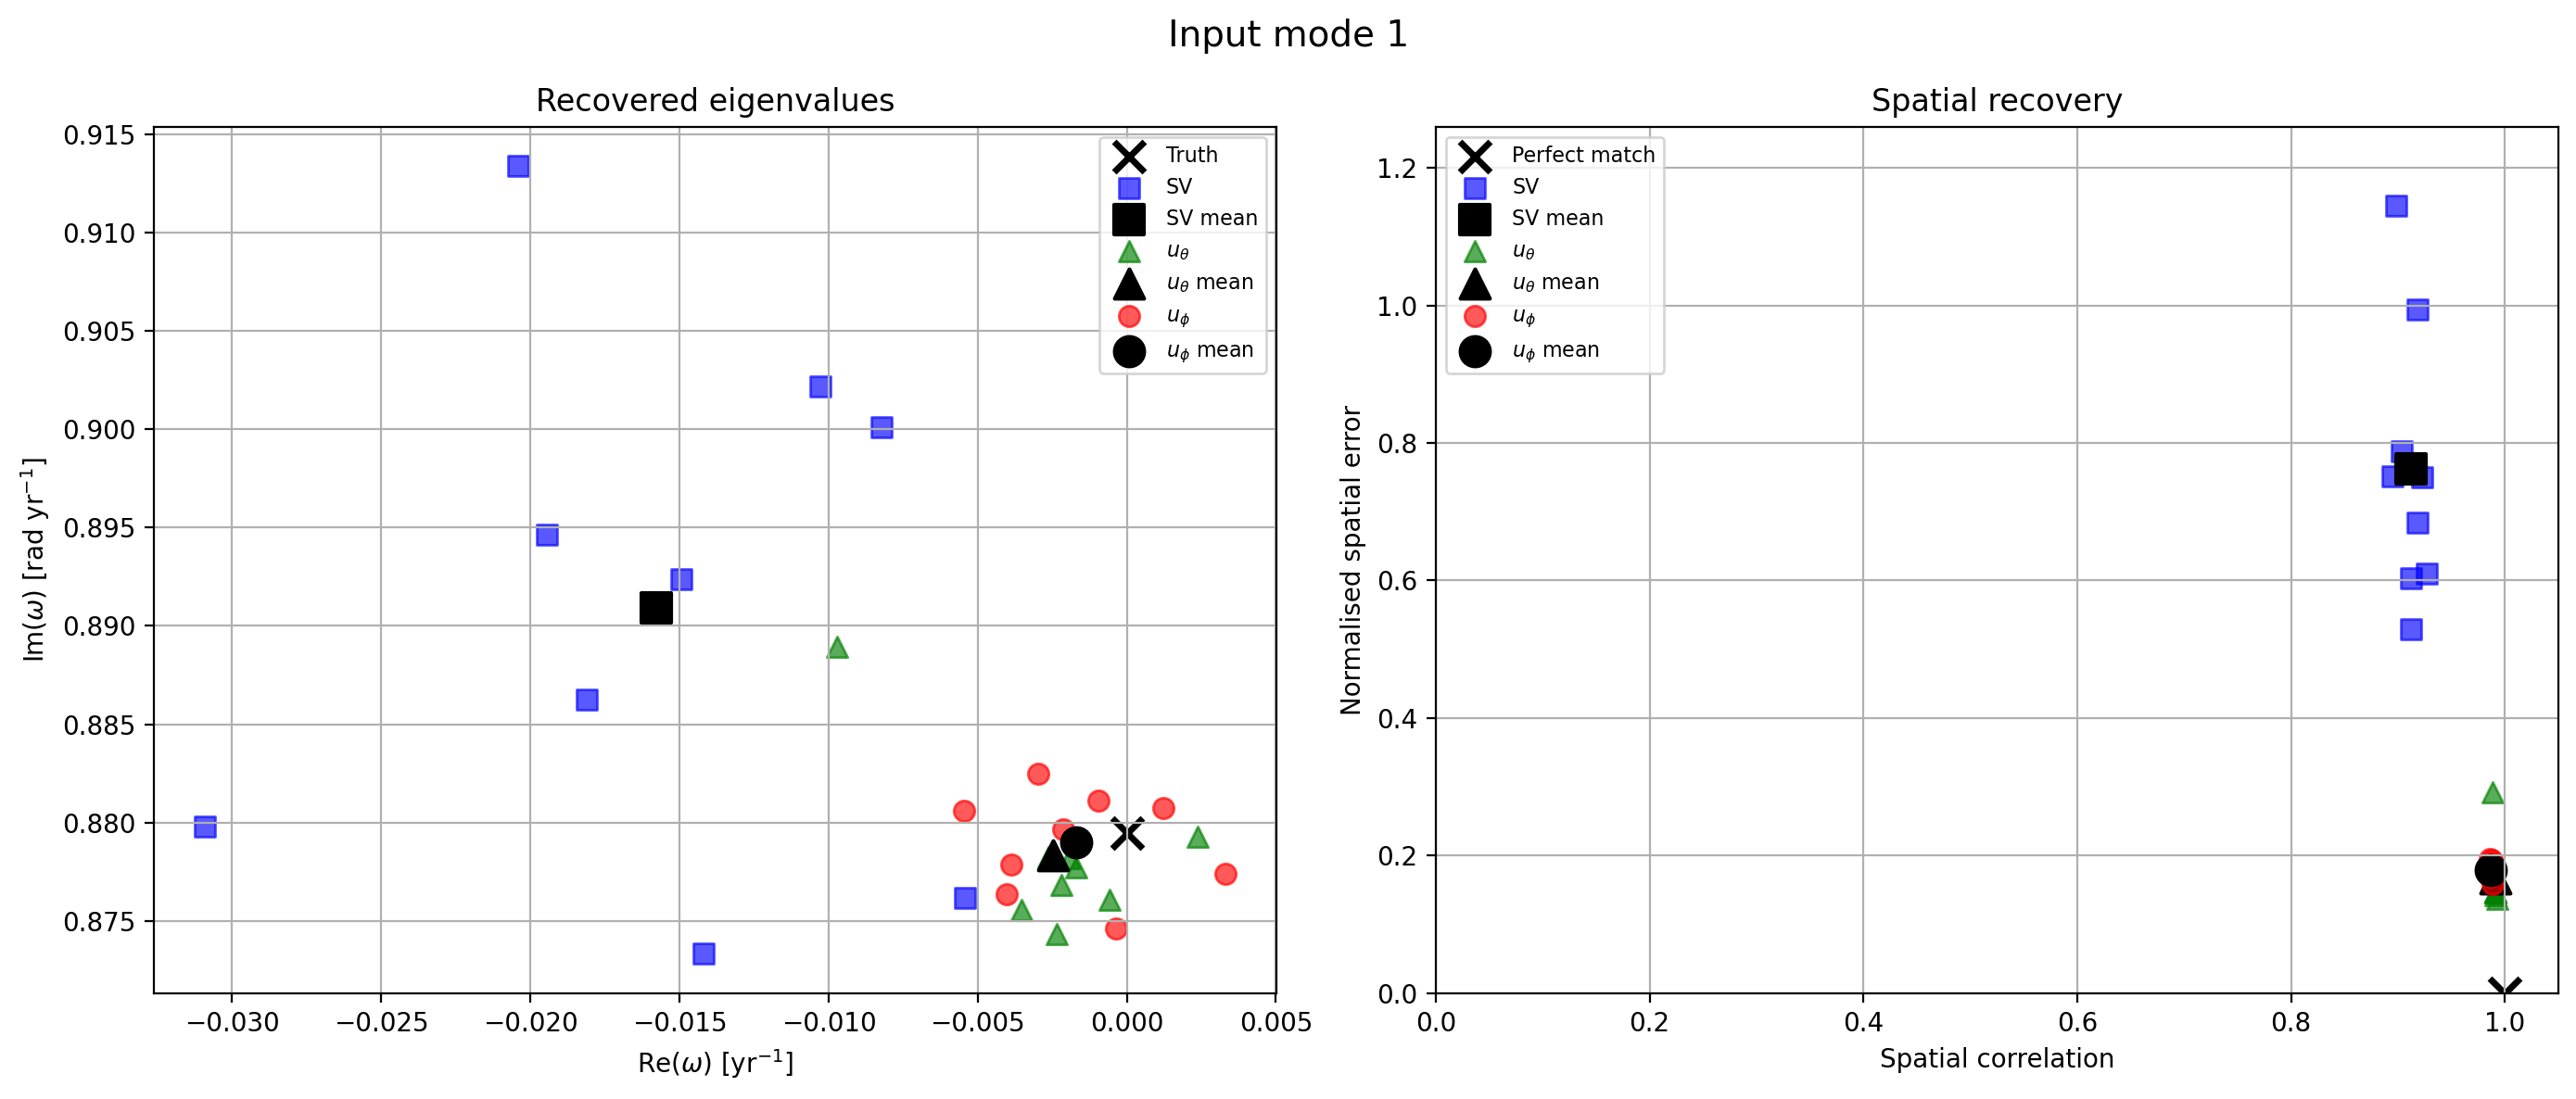

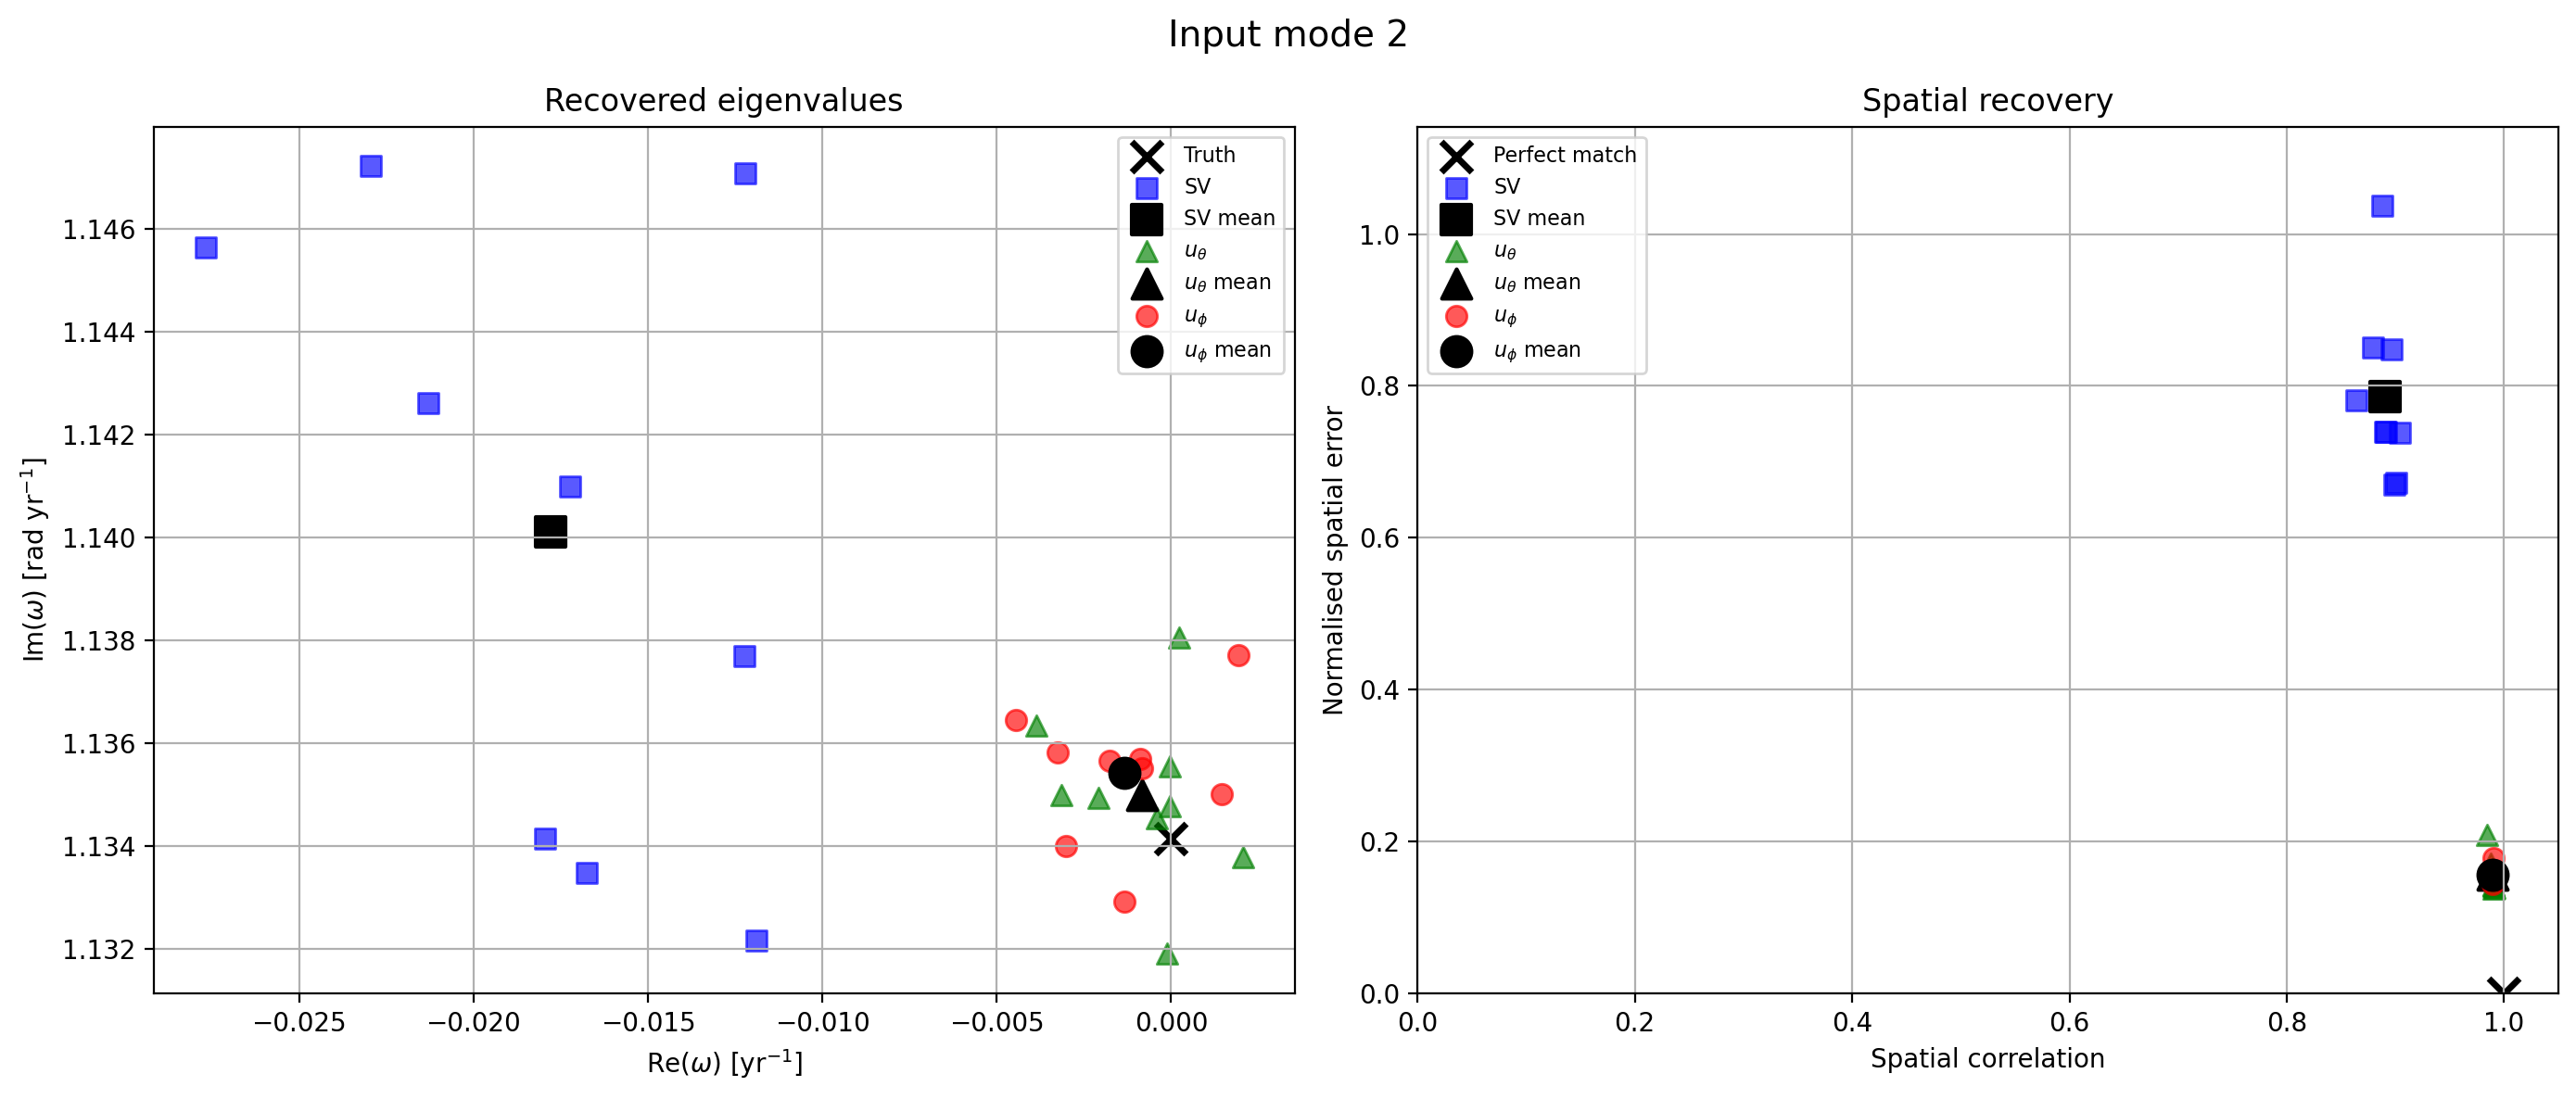

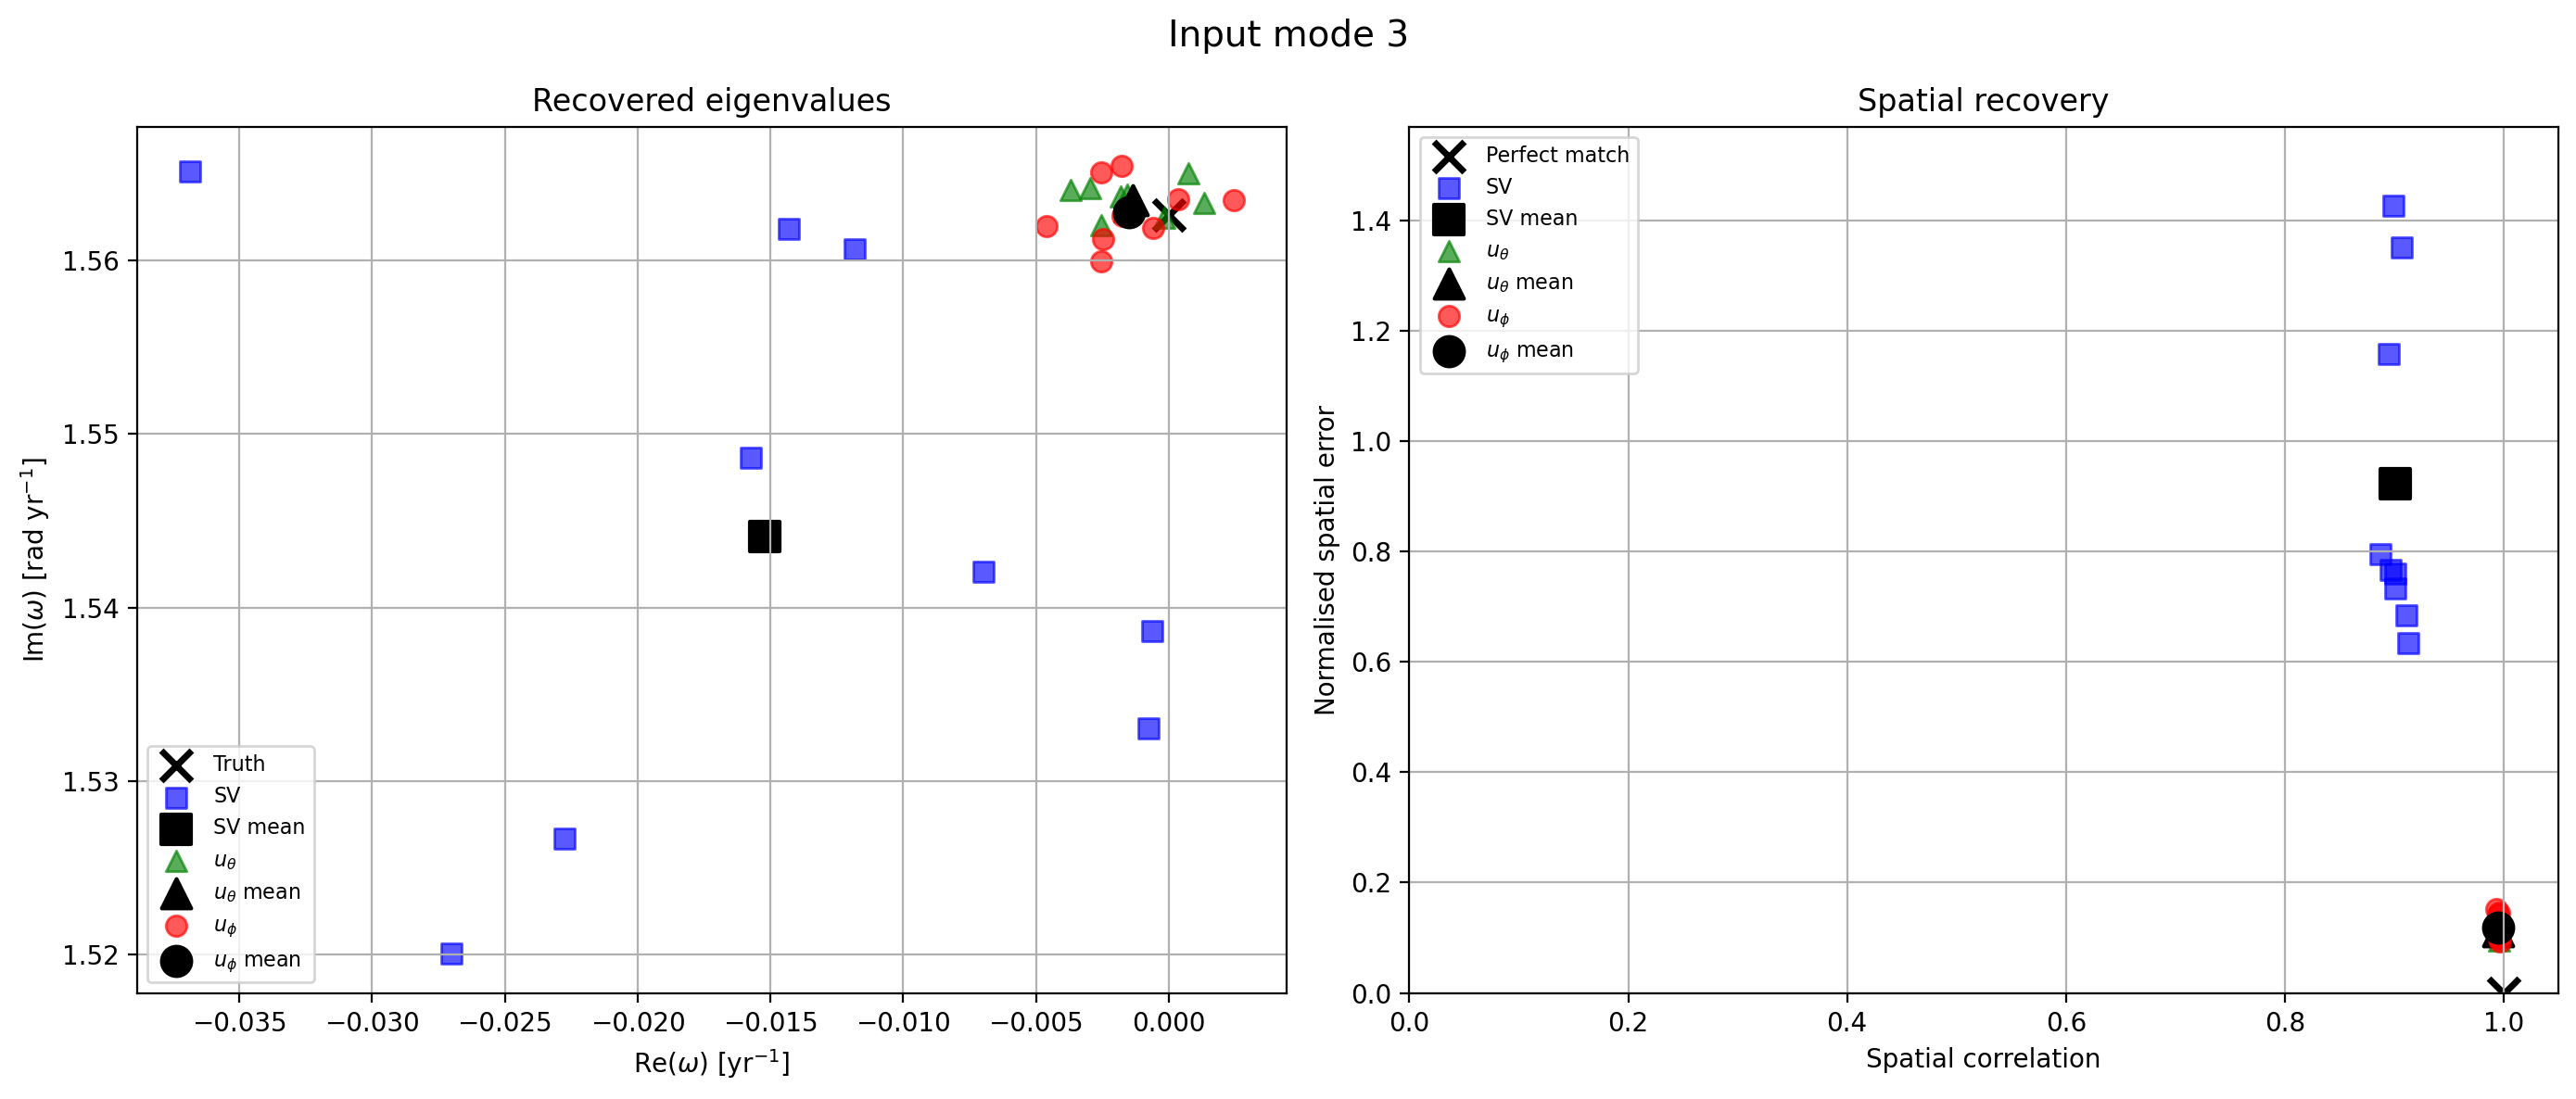

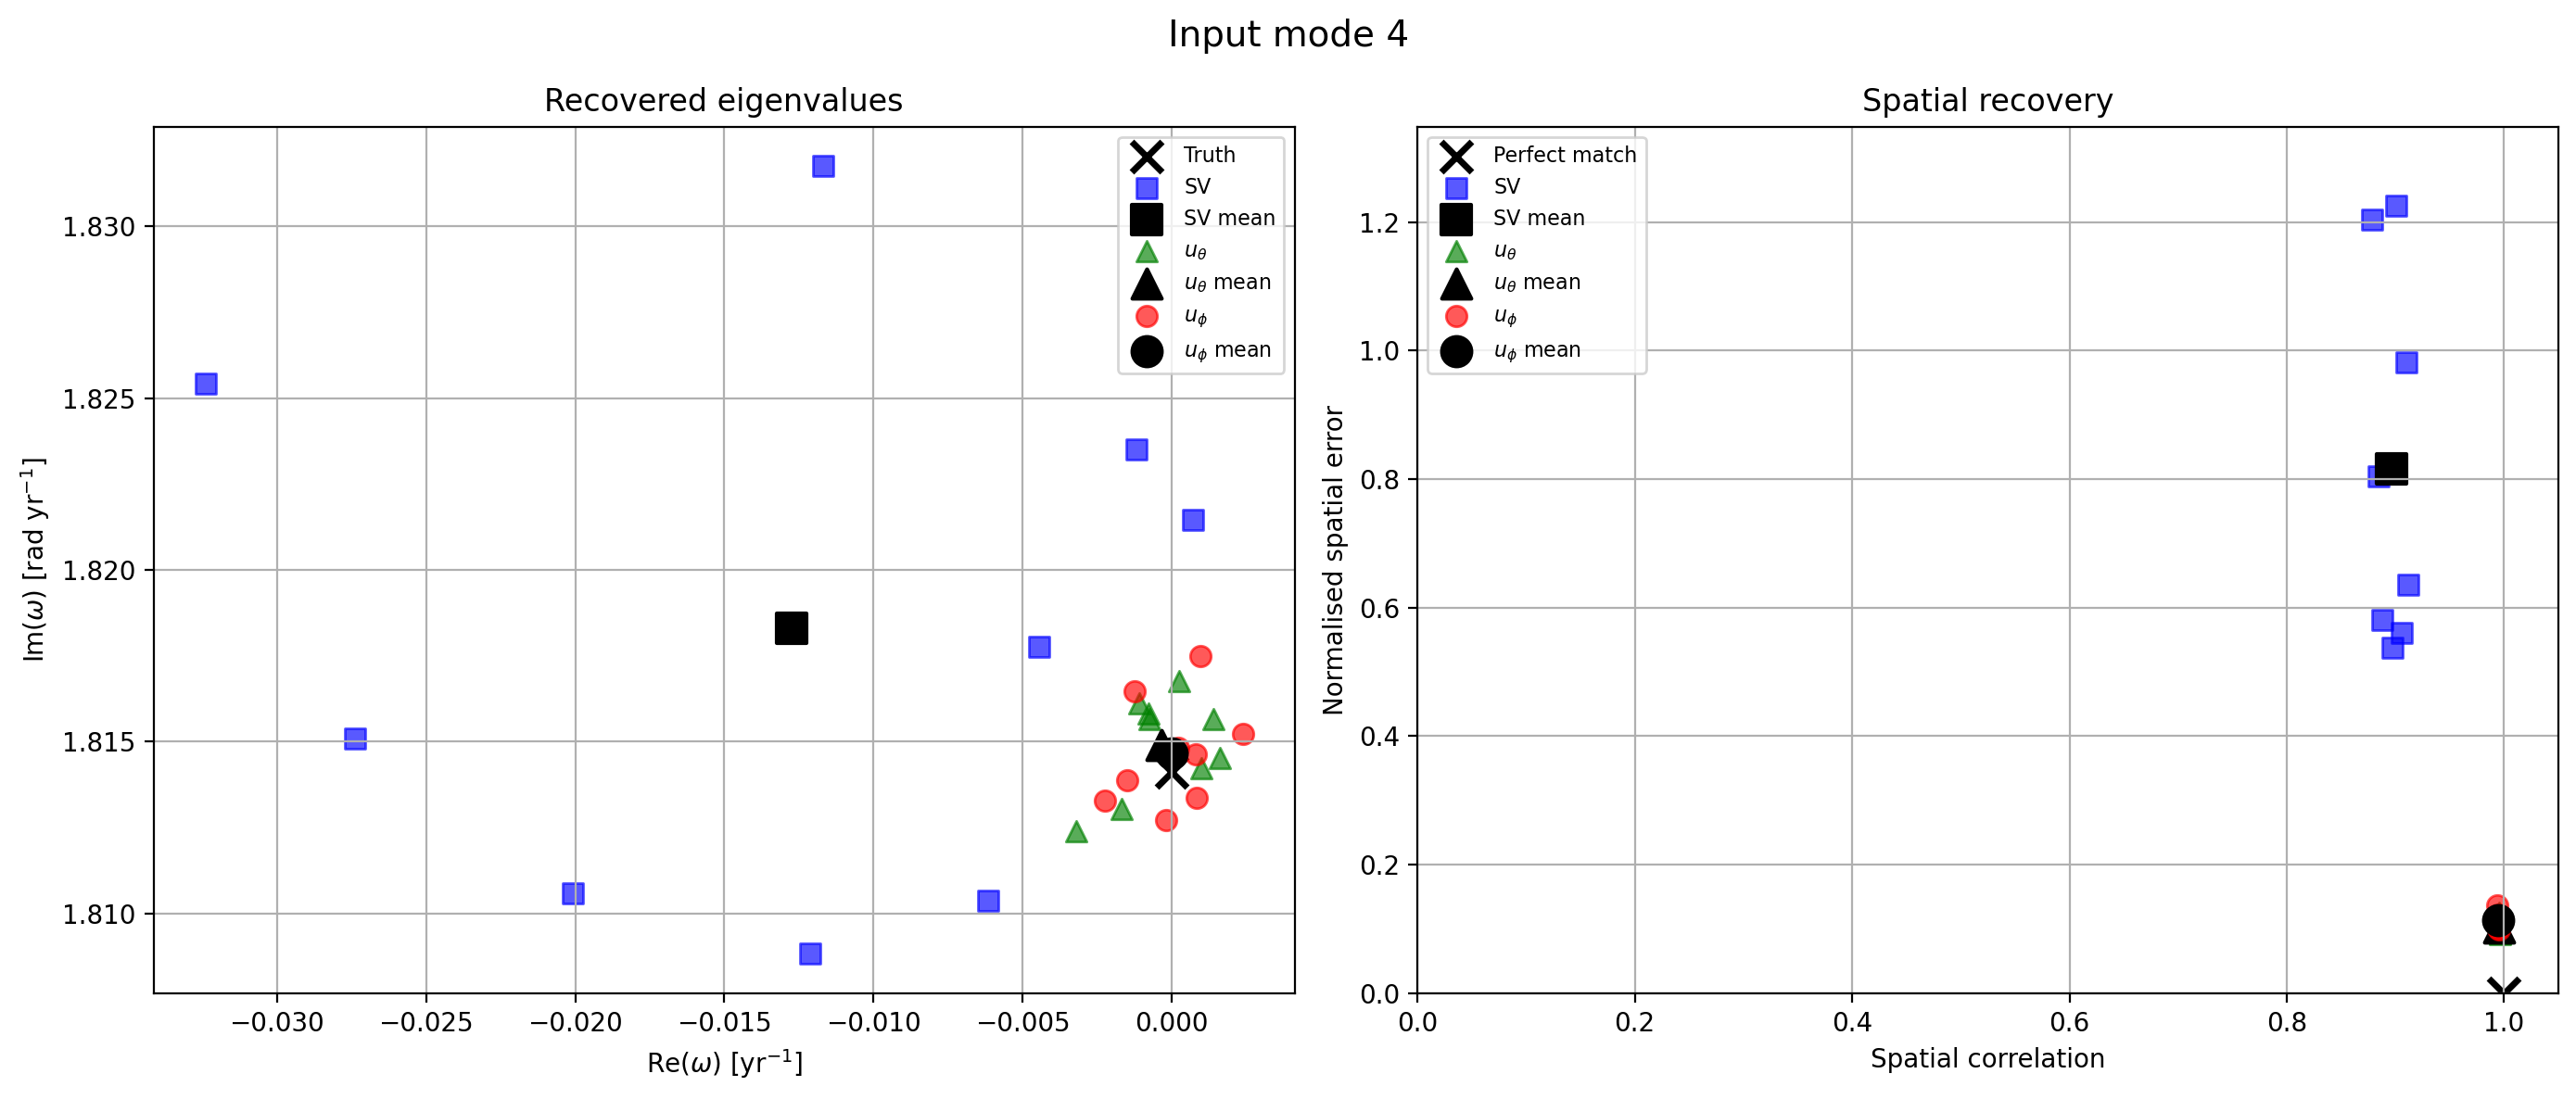

In [ ]:
plot_performance_summary(performance_summary, save_dir=OUT_DIR)

In [ ]:
# plotting the analytic spectrums
full_power_suite = Felix_Power_Suite(input_wave_data)

wave_power_suite = full_power_suite[:-1]
f = np.asarray([data_row["frequency"] for data_row in wave_power_suite])

psd_by_component = {
    "frequency":f, 
    "psd":{
        "sv":None,
        "utheta":None,
        "uphi":None,
    }
}

for c in psd_by_component["psd"]:
    psd_by_component["psd"][c]=np.asarray([data_row["field_power"][c] for data_row in wave_power_suite])/ (1/25)

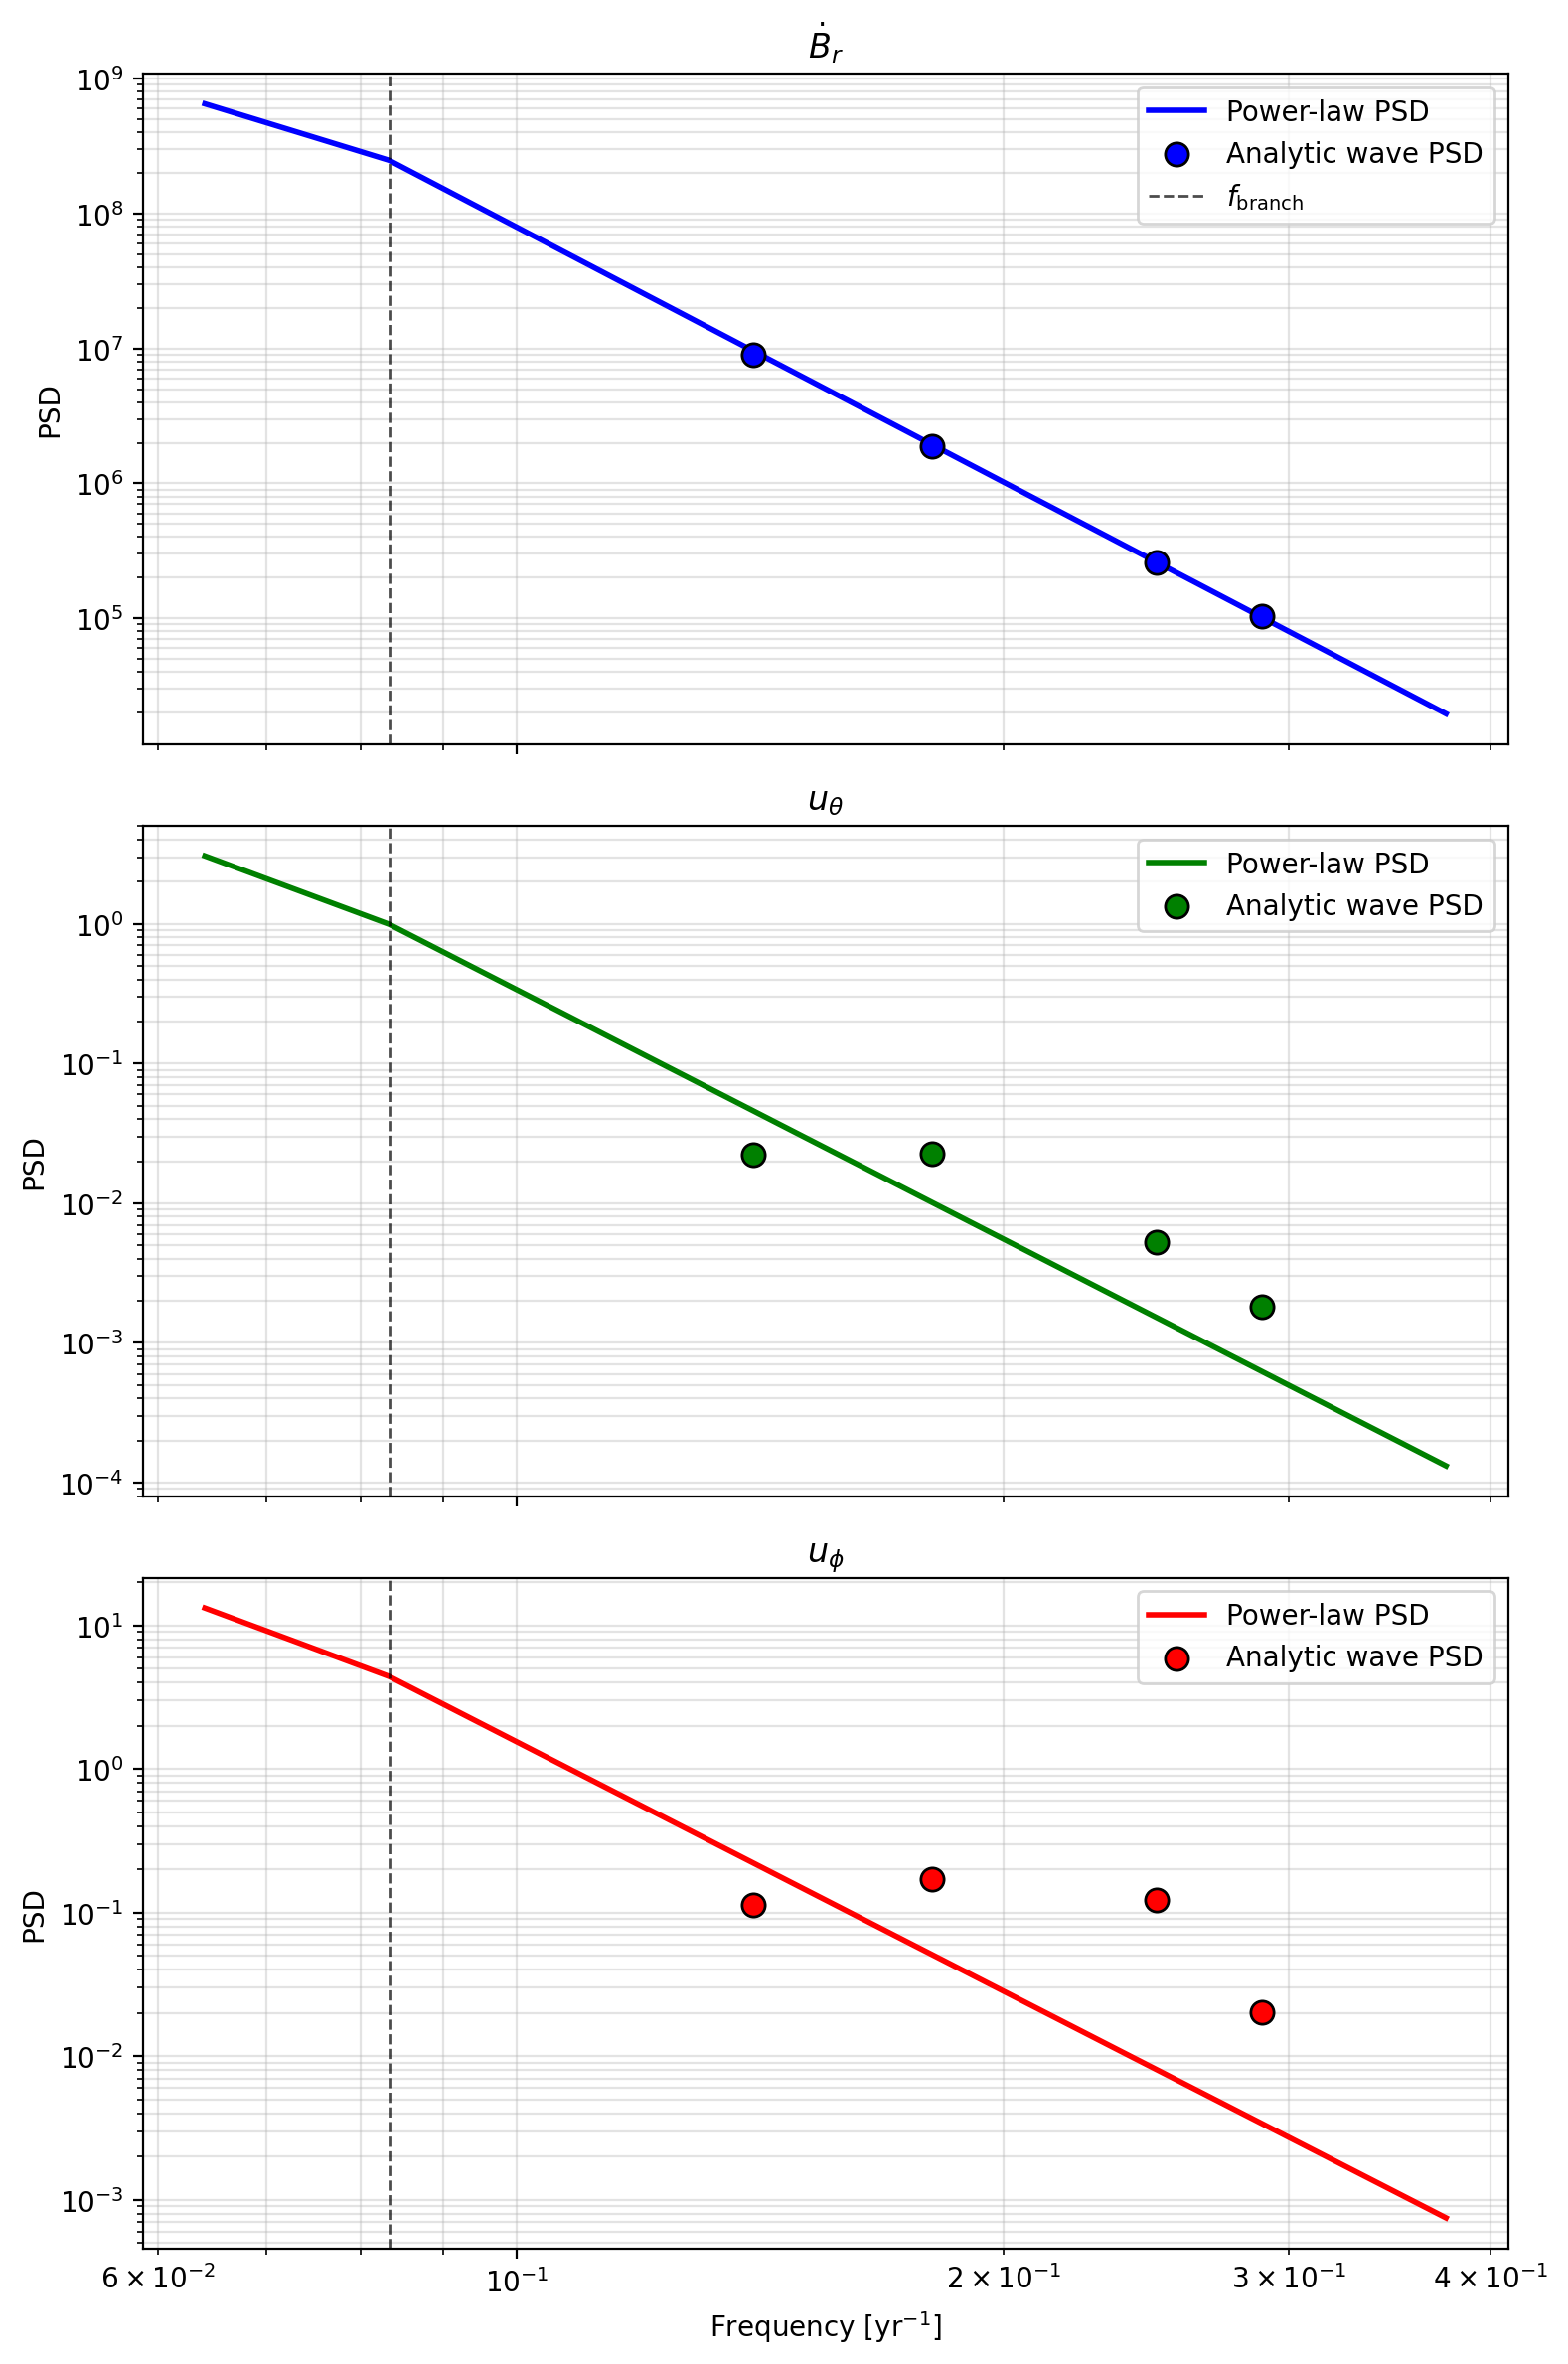

In [ ]:
plot_power_law_with_analytic_wave_psd(
    power_law_psd_dict,
    psd_by_component,
    save_path="figures/power_law_vs_analytic_wave_psd.png",
    show=True
)

In [ ]:
Cube_Movie(noise_sv)

'figures/data_cube.mp4'

TypeError: 'NoneType' object is not subscriptable

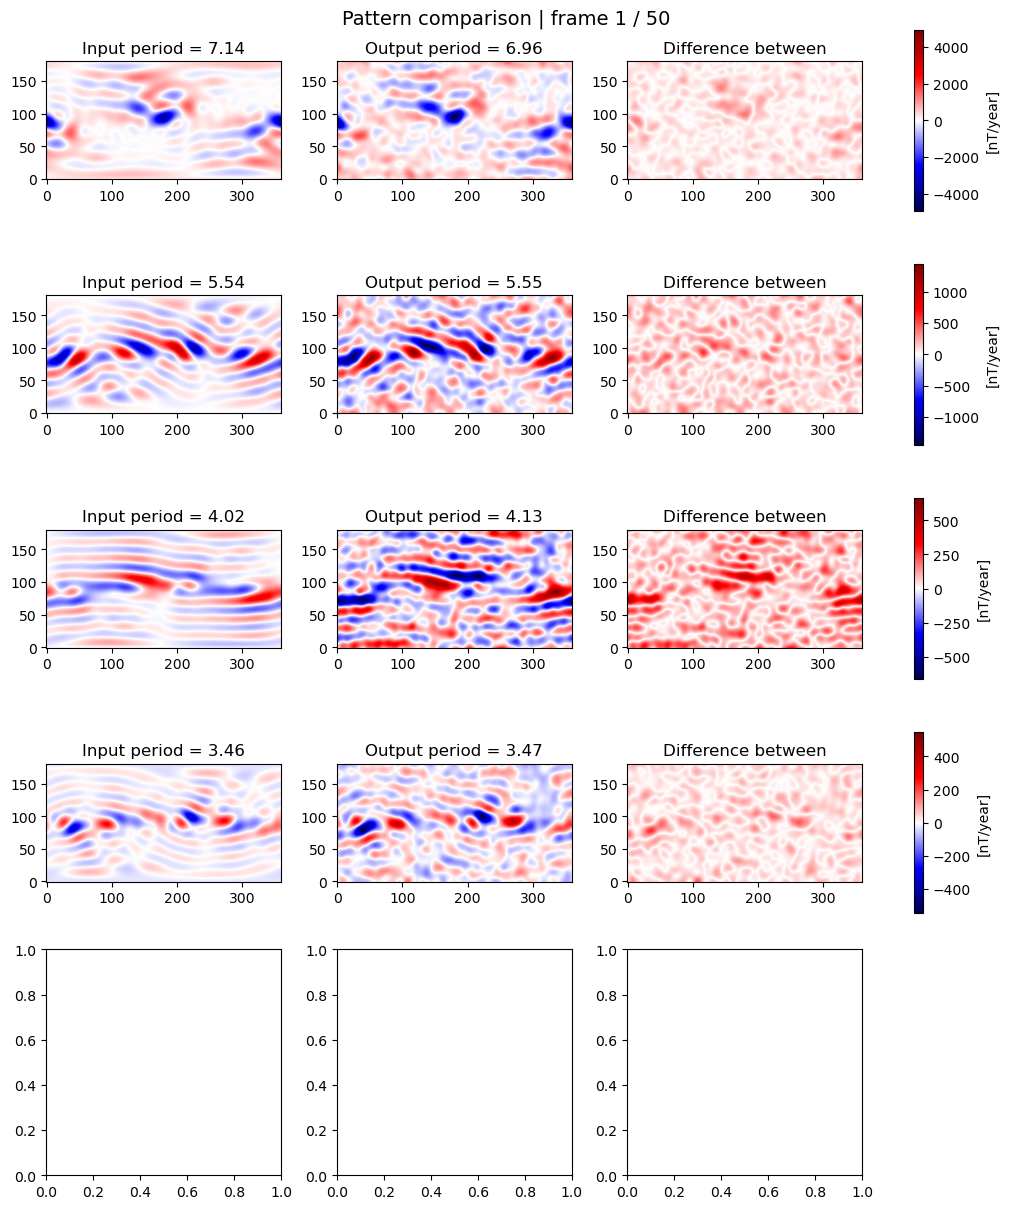

In [ ]:
c = "sv"
Video_Compare(input_wave_data, output_mode_data, tot_input_dict[c], tot_output_dict[c], times=times_dyear, c=c)

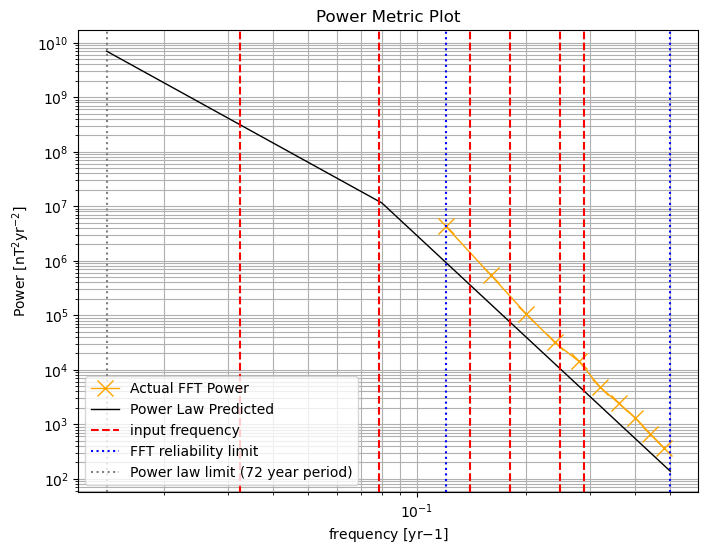

In [ ]:
# get power quality control
input_wave_freqs = [arr["eigenvalue"].imag/(2*np.pi) for arr in input_wave_data]
Power_QC(noise_sv, times_dyear, input_wave_freqs, scaling='spectrum', window='hann', limits=True)